In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------------
# 1. Load checkpoint
# ------------------------------------------------------------------
checkpoint_path = Path(
    r"C:\study\Master_papers\Robust MM\CaMuRe\saved"
    r"\MASKED_GLORIA-book-seed999-Aug-12-2026-13-46-25.pth"
)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )
except TypeError:
    # Compatibility with older PyTorch versions
    checkpoint = torch.load(checkpoint_path, map_location="cpu")

state_dict = checkpoint.get("state_dict", checkpoint)

# Locate mask_logits, including checkpoints saved with a "module." prefix.
candidate_keys = [
    key for key in state_dict
    if key == "mask_logits" or key.endswith(".mask_logits")
]

if len(candidate_keys) != 1:
    raise KeyError(
        f"Expected exactly one mask_logits tensor, found: {candidate_keys}"
    )

mask_key = candidate_keys[0]
final_logits = state_dict[mask_key].detach().float().cpu().flatten()

# M_e = sigmoid(theta_e)
final_mask = torch.sigmoid(final_logits).numpy()

# masked_gloria.py initializes mask_logits with zeros.
initial_mask = torch.full_like(final_logits, 0.5).numpy()

print(f"Checkpoint: {checkpoint_path.name}")
print(f"Mask key:   {mask_key}")
print(f"Edges:      {final_mask.size:,}")

Checkpoint: MASKED_GLORIA-book-seed999-Aug-12-2026-13-46-25.pth
Mask key:   mask_logits
Edges:      120,464


In [3]:
def summarize_mask(mask):
    mask = np.asarray(mask)

    return {
        "count": mask.size,
        "mean": np.mean(mask),
        "std": np.std(mask),
        "median": np.median(mask),
        "min": np.min(mask),
        "p01": np.percentile(mask, 1),
        "p05": np.percentile(mask, 5),
        "p10": np.percentile(mask, 10),
        "p25": np.percentile(mask, 25),
        "p75": np.percentile(mask, 75),
        "p90": np.percentile(mask, 90),
        "p95": np.percentile(mask, 95),
        "p99": np.percentile(mask, 99),
        "max": np.max(mask),
        "fraction M < 0.2": np.mean(mask < 0.2),
        "fraction M > 0.8": np.mean(mask > 0.8),
        "fraction 0.48 <= M <= 0.52": np.mean(
            (mask >= 0.48) & (mask <= 0.52)
        ),
    }


summary = pd.DataFrame({
    "initial": summarize_mask(initial_mask),
    "final": summarize_mask(final_mask),
})

display(summary.round(6))

,initial,final
count,120464.0,120464.000000
mean,0.5,0.947312
std,0.0,0.091126
median,0.5,0.975930
min,0.5,0.021638
p01,0.5,0.483213
p05,0.5,0.801323
p10,0.5,0.889869
p25,0.5,0.953126
p75,0.5,0.985033


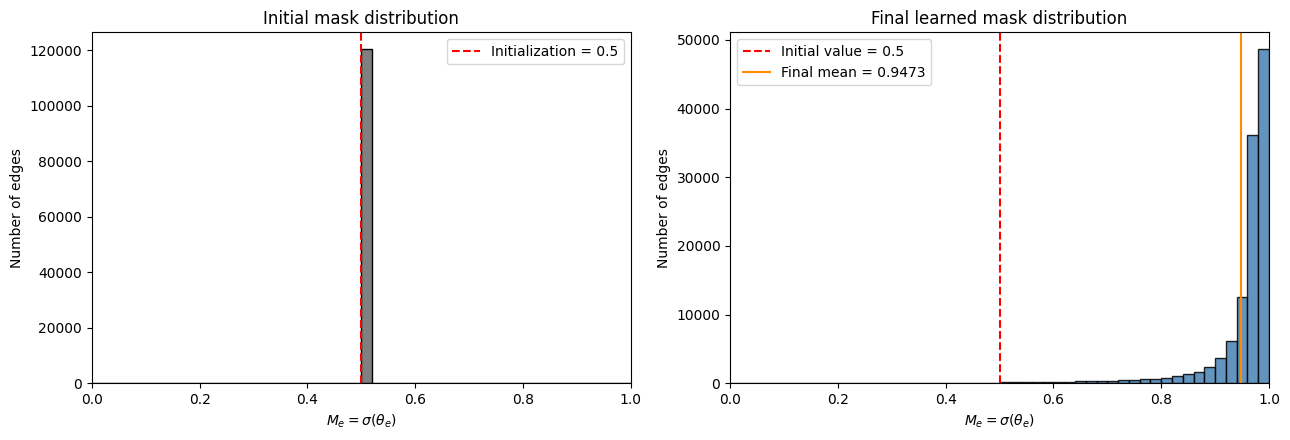

In [4]:
bins = np.linspace(0.0, 1.0, 51)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Initial distribution
axes[0].hist(
    initial_mask,
    bins=bins,
    color="gray",
    edgecolor="black",
)
axes[0].set_title("Initial mask distribution")
axes[0].set_xlabel(r"$M_e = \sigma(\theta_e)$")
axes[0].set_ylabel("Number of edges")
axes[0].set_xlim(0, 1)
axes[0].axvline(
    0.5,
    color="red",
    linestyle="--",
    label="Initialization = 0.5",
)
axes[0].legend()

# Final learned distribution
axes[1].hist(
    final_mask,
    bins=bins,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
)
axes[1].set_title("Final learned mask distribution")
axes[1].set_xlabel(r"$M_e = \sigma(\theta_e)$")
axes[1].set_ylabel("Number of edges")
axes[1].set_xlim(0, 1)
axes[1].axvline(
    0.5,
    color="red",
    linestyle="--",
    label="Initial value = 0.5",
)
axes[1].axvline(
    final_mask.mean(),
    color="darkorange",
    linestyle="-",
    label=f"Final mean = {final_mask.mean():.4f}",
)
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
near_half_fraction = np.mean(
    (final_mask >= 0.48) & (final_mask <= 0.52)
)

print(f"Final standard deviation: {final_mask.std():.6f}")
print(f"Fraction within [0.48, 0.52]: {near_half_fraction:.2%}")
print(f"Fraction below 0.2: {np.mean(final_mask < 0.2):.2%}")
print(f"Fraction above 0.8: {np.mean(final_mask > 0.8):.2%}")

if near_half_fraction > 0.90:
    print(
        "Interpretation: most masks remain close to initialization; "
        "there is little edge differentiation."
    )
elif final_mask.std() < 0.05:
    print(
        "Interpretation: the masks moved, but their distribution remains narrow."
    )
else:
    print(
        "Interpretation: the model learned heterogeneous edge weights. "
        "Further analysis is needed to determine whether that "
        "heterogeneity is structurally meaningful."
    )

Final standard deviation: 0.091126
Fraction within [0.48, 0.52]: 0.20%
Fraction below 0.2: 0.17%
Fraction above 0.8: 95.04%
Interpretation: the model learned heterogeneous edge weights. Further analysis is needed to determine whether that heterogeneity is structurally meaningful.


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr, spearmanr


# ================================================================
# 1. Configuration
# ================================================================
checkpoint_path = Path(
    r"C:\study\Master_papers\Robust MM\CaMuRe\saved"
    r"\MASKED_GLORIA-book-seed999-Aug-12-2026-13-46-25.pth"
)

interaction_path = Path(
    r"C:\study\Master_papers\Robust MM\CaMuRe\data\book\book.inter"
)

USER_COL = "userID"
ITEM_COL = "itemID"
SPLIT_COL = "x_label"
TRAIN_SPLIT = 0


# ================================================================
# 2. Load learned mask
# ================================================================
try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")

state_dict = checkpoint.get("state_dict", checkpoint)

mask_keys = [
    key for key in state_dict
    if key == "mask_logits" or key.endswith(".mask_logits")
]

if len(mask_keys) != 1:
    raise KeyError(
        f"Expected one mask_logits tensor, found: {mask_keys}"
    )

mask_key = mask_keys[0]
mask_logits = state_dict[mask_key].detach().float().cpu().flatten()
learned_mask = torch.sigmoid(mask_logits).numpy().astype(np.float64)

print(f"Checkpoint: {checkpoint_path.name}")
print(f"Mask key:   {mask_key}")
print(f"Masks:      {len(learned_mask):,}")


# ================================================================
# 3. Recover training edges in the same order used by the model
# ================================================================
all_interactions = pd.read_csv(interaction_path, sep="\t")

train_edges = (
    all_interactions.loc[
        all_interactions[SPLIT_COL] == TRAIN_SPLIT,
        [USER_COL, ITEM_COL],
    ]
    .copy()
    .reset_index(drop=True)
)

if len(train_edges) != len(learned_mask):
    raise ValueError(
        "Checkpoint and dataset do not match:\n"
        f"Training edges: {len(train_edges):,}\n"
        f"Mask values:    {len(learned_mask):,}"
    )

user_ids = train_edges[USER_COL].to_numpy(dtype=np.int64)
item_ids = train_edges[ITEM_COL].to_numpy(dtype=np.int64)

num_users = int(all_interactions[USER_COL].max()) + 1
num_items = int(all_interactions[ITEM_COL].max()) + 1


# ================================================================
# 4. Compute raw and normalized degrees
# ================================================================
user_degree = np.bincount(
    user_ids,
    minlength=num_users,
).astype(np.float64)

item_degree = np.bincount(
    item_ids,
    minlength=num_items,
).astype(np.float64)


def log_minmax_normalize(degree):
    """log1p followed by min-max normalization."""
    degree = np.asarray(degree, dtype=np.float64)
    transformed = np.log1p(degree)

    minimum = transformed.min()
    maximum = transformed.max()

    if maximum - minimum < 1e-12:
        return np.zeros_like(transformed)

    return (transformed - minimum) / (maximum - minimum)


user_degree_norm = log_minmax_normalize(user_degree)
item_degree_norm = log_minmax_normalize(item_degree)

# Edge-level structural values
du = user_degree_norm[user_ids]
di = item_degree_norm[item_ids]

# q_ui = d_u * (1 - d_i)
q_ui = du * (1.0 - di)

edge_analysis = train_edges.copy()
edge_analysis["user_degree"] = user_degree[user_ids]
edge_analysis["item_degree"] = item_degree[item_ids]
edge_analysis["du"] = du
edge_analysis["di"] = di
edge_analysis["q_ui"] = q_ui
edge_analysis["mask"] = learned_mask

display(edge_analysis.head())

Checkpoint: MASKED_GLORIA-book-seed999-Aug-12-2026-13-46-25.pth
Mask key:   mask_logits
Masks:      120,464


,userID,itemID,user_degree,item_degree,du,di,q_ui,mask
0,0,0,3.0,9.0,0.143088,0.334169,0.095273,0.974100
1,0,1,3.0,5.0,0.143088,0.228106,0.110449,0.978792
2,0,2,3.0,30.0,0.143088,0.569083,0.061659,0.934533
3,1,3,28.0,6.0,0.552032,0.260112,0.408442,0.966487
4,1,4,28.0,14.0,0.552032,0.418356,0.321086,0.939706


In [7]:
def correlation_result(x, y, name):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    return {
        "relationship": name,
        "Pearson r": pearson_r,
        "Pearson p": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman p": spearman_p,
    }


correlation_table = pd.DataFrame([
    correlation_result(
        learned_mask,
        du,
        "Mask vs user degree",
    ),
    correlation_result(
        learned_mask,
        di,
        "Mask vs item degree",
    ),
    correlation_result(
        learned_mask,
        q_ui,
        "Mask vs niche score q_ui",
    ),
]).set_index("relationship")

display(correlation_table)

,Pearson r,Pearson p,Spearman rho,Spearman p
relationship,,,,
Mask vs user degree,-0.094445,1.034199e-236,-0.072963,7.428046e-142
Mask vs item degree,-0.003740,1.942297e-01,-0.002323,4.200774e-01
Mask vs niche score q_ui,-0.070903,4.744454e-134,-0.051820,2.036928e-72


In [8]:
# Median normalized degree among nodes that occur in training.
user_threshold = np.median(
    user_degree_norm[user_degree > 0]
)
item_threshold = np.median(
    item_degree_norm[item_degree > 0]
)

high_user = du >= user_threshold
high_item = di >= item_threshold

edge_analysis["group"] = np.select(
    [
        high_user & high_item,
        high_user & ~high_item,
        ~high_user & high_item,
        ~high_user & ~high_item,
    ],
    [
        "mainstream (high/high)",
        "niche (high/low)",
        "popular exposure (low/high)",
        "sparse (low/low)",
    ],
)

group_order = [
    "mainstream (high/high)",
    "niche (high/low)",
    "popular exposure (low/high)",
    "sparse (low/low)",
]

group_summary = (
    edge_analysis.groupby("group", observed=True)["mask"]
    .agg(
        n_edges="size",
        mean="mean",
        median="median",
        std="std",
        p25=lambda x: np.percentile(x, 25),
        p75=lambda x: np.percentile(x, 75),
    )
    .reindex(group_order)
)

group_summary["edge_fraction"] = (
    group_summary["n_edges"] / len(edge_analysis)
)

print(f"User threshold: {user_threshold:.6f}")
print(f"Item threshold: {item_threshold:.6f}")

display(group_summary.round(6))

User threshold: 0.286177
Item threshold: 0.334169


,n_edges,mean,median,std,p25,p75,edge_fraction
group,,,,,,,
mainstream (high/high),78144,0.945179,0.975633,0.094831,0.951633,0.984965,0.648692
niche (high/low),20608,0.946416,0.975693,0.092682,0.951681,0.985018,0.171072
popular exposure (low/high),17589,0.955828,0.977114,0.073942,0.958743,0.985260,0.146010
sparse (low/low),4123,0.955892,0.977082,0.073822,0.959088,0.985430,0.034226


In [9]:
mainstream = edge_analysis.loc[
    edge_analysis["group"] == "mainstream (high/high)",
    "mask",
].to_numpy()

niche = edge_analysis.loc[
    edge_analysis["group"] == "niche (high/low)",
    "mask",
].to_numpy()

mean_difference = niche.mean() - mainstream.mean()
median_difference = np.median(niche) - np.median(mainstream)

comparison = pd.Series({
    "niche mean": niche.mean(),
    "mainstream mean": mainstream.mean(),
    "niche - mainstream mean": mean_difference,
    "niche median": np.median(niche),
    "mainstream median": np.median(mainstream),
    "niche - mainstream median": median_difference,
})

display(comparison.to_frame("value").round(6))

if mean_difference > 0:
    print("The mean-mask result supports the high-user/low-item hypothesis.")
else:
    print("The mean-mask result does not support the hypothesis.")

,value
niche mean,0.946416
mainstream mean,0.945179
niche - mainstream mean,0.001238
niche median,0.975693
mainstream median,0.975633
niche - mainstream median,0.000060


The mean-mask result supports the high-user/low-item hypothesis.


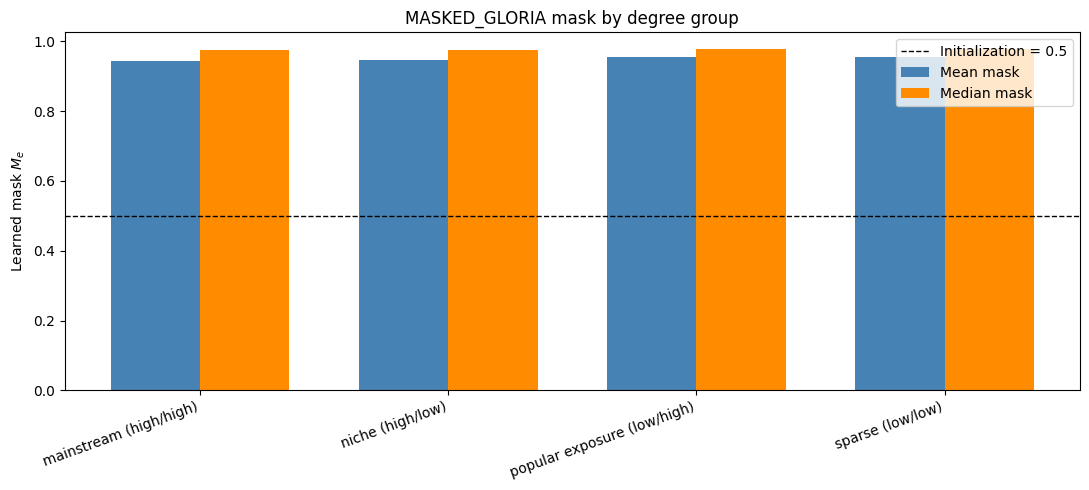

In [10]:
plot_summary = group_summary.dropna()
x = np.arange(len(plot_summary))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    x - width / 2,
    plot_summary["mean"],
    width,
    label="Mean mask",
    color="steelblue",
)

ax.bar(
    x + width / 2,
    plot_summary["median"],
    width,
    label="Median mask",
    color="darkorange",
)

ax.axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initialization = 0.5",
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_summary.index,
    rotation=20,
    ha="right",
)
ax.set_ylabel(r"Learned mask $M_e$")
ax.set_title("MASKED_GLORIA mask by degree group")
ax.legend()

plt.tight_layout()
plt.show()

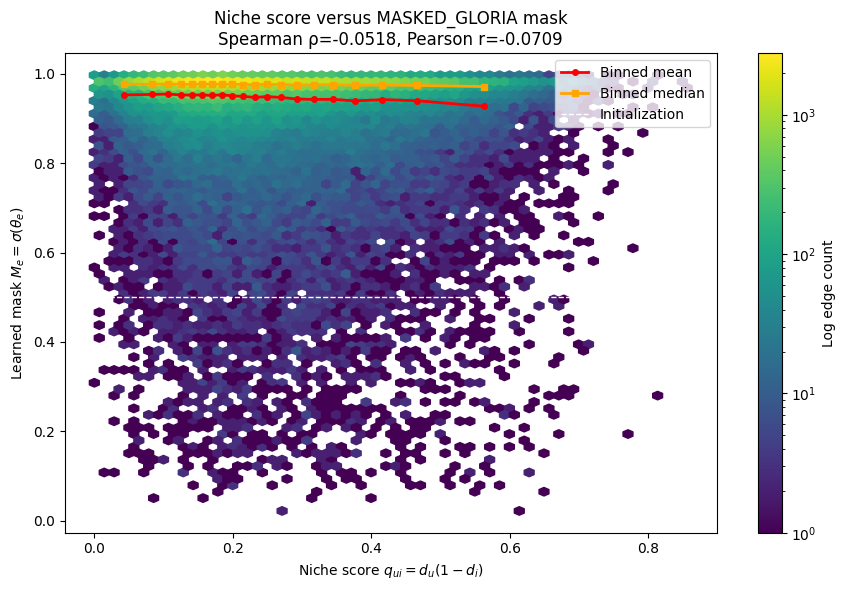

Spearman rho: -0.051820
Spearman p:   2.03693e-72
Pearson r:    -0.070903
Pearson p:    4.74445e-134


,q_mean,mask_mean,mask_median,n_edges
0,0.042313,0.952812,0.976741,6024
1,0.082871,0.953899,0.976719,6030
2,0.106227,0.954752,0.977317,6027
3,0.124904,0.952762,0.976668,6019
4,0.140722,0.952534,0.976301,6055
5,0.155855,0.952849,0.977156,6110
6,0.170177,0.951567,0.976712,5940
7,0.184376,0.953197,0.976869,5981
8,0.199277,0.950667,0.976743,6277
9,0.215231,0.949457,0.976060,5772


In [11]:
q_spearman, q_spearman_p = spearmanr(q_ui, learned_mask)
q_pearson, q_pearson_p = pearsonr(q_ui, learned_mask)

# Quantile-binned trend
edge_analysis["q_bin"] = pd.qcut(
    edge_analysis["q_ui"],
    q=20,
    duplicates="drop",
)

q_trend = (
    edge_analysis.groupby("q_bin", observed=True)
    .agg(
        q_mean=("q_ui", "mean"),
        mask_mean=("mask", "mean"),
        mask_median=("mask", "median"),
        n_edges=("mask", "size"),
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

density_plot = ax.hexbin(
    edge_analysis["q_ui"],
    edge_analysis["mask"],
    gridsize=60,
    mincnt=1,
    bins="log",
    cmap="viridis",
)

ax.plot(
    q_trend["q_mean"],
    q_trend["mask_mean"],
    color="red",
    marker="o",
    linewidth=2,
    markersize=4,
    label="Binned mean",
)

ax.plot(
    q_trend["q_mean"],
    q_trend["mask_median"],
    color="orange",
    marker="s",
    linewidth=2,
    markersize=4,
    label="Binned median",
)

ax.axhline(
    0.5,
    color="white",
    linestyle="--",
    linewidth=1,
    label="Initialization",
)

colorbar = fig.colorbar(density_plot, ax=ax)
colorbar.set_label("Log edge count")

ax.set_xlabel(r"Niche score $q_{ui}=d_u(1-d_i)$")
ax.set_ylabel(r"Learned mask $M_e=\sigma(\theta_e)$")
ax.set_title(
    "Niche score versus MASKED_GLORIA mask\n"
    f"Spearman ρ={q_spearman:.4f}, "
    f"Pearson r={q_pearson:.4f}"
)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Spearman rho: {q_spearman:.6f}")
print(f"Spearman p:   {q_spearman_p:.6g}")
print(f"Pearson r:    {q_pearson:.6f}")
print(f"Pearson p:    {q_pearson_p:.6g}")

display(q_trend.round(6))

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

USER_COL = "userID"
ITEM_COL = "itemID"

required_columns = {
    USER_COL,
    ITEM_COL,
    "mask",
    "du",
    "di",
    "q_ui",
    "user_degree",
    "item_degree",
}

missing_columns = required_columns - set(edge_analysis.columns)

if missing_columns:
    raise ValueError(
        f"edge_analysis is missing columns: {sorted(missing_columns)}"
    )

analysis = edge_analysis.reset_index(drop=True).copy()
n_edges = len(analysis)

# Stable sorting ensures reproducibility if multiple masks are tied.
mask_order = np.argsort(
    analysis["mask"].to_numpy(),
    kind="stable",
)

tail_definitions = {
    "Bottom 1%": ("bottom_01", 0.01),
    "Bottom 5%": ("bottom_05", 0.05),
    "Bottom 10%": ("bottom_10", 0.10),
}

tail_information = []

for label, (column, fraction) in tail_definitions.items():
    n_selected = max(1, int(np.ceil(fraction * n_edges)))

    flag = np.zeros(n_edges, dtype=bool)
    flag[mask_order[:n_selected]] = True
    analysis[column] = flag

    selected_masks = analysis.loc[flag, "mask"]

    tail_information.append({
        "tail": label,
        "n_edges": n_selected,
        "fraction": n_selected / n_edges,
        "maximum_mask": selected_masks.max(),
        "mean_mask": selected_masks.mean(),
        "median_mask": selected_masks.median(),
    })

tail_information = pd.DataFrame(tail_information).set_index("tail")

display(tail_information.round(6))

,n_edges,fraction,maximum_mask,mean_mask,median_mask
tail,,,,,
Bottom 1%,1205,0.010003,0.483204,0.325622,0.348031
Bottom 5%,6024,0.050007,0.801319,0.617446,0.674343
Bottom 10%,12047,0.100005,0.889864,0.735782,0.801319


In [13]:
# One record per active user/item
active_users = analysis[
    [USER_COL, "user_degree", "du"]
].drop_duplicates(USER_COL)

active_items = analysis[
    [ITEM_COL, "item_degree", "di"]
].drop_duplicates(ITEM_COL)

user_threshold = active_users["du"].median()
item_threshold = active_items["di"].median()

high_user = analysis["du"] >= user_threshold
high_item = analysis["di"] >= item_threshold

analysis["degree_group"] = np.select(
    [
        high_user & high_item,
        high_user & ~high_item,
        ~high_user & high_item,
        ~high_user & ~high_item,
    ],
    [
        "mainstream (high/high)",
        "niche (high/low)",
        "popular exposure (low/high)",
        "sparse (low/low)",
    ],
)

degree_group_order = [
    "mainstream (high/high)",
    "niche (high/low)",
    "popular exposure (low/high)",
    "sparse (low/low)",
]

print(f"User high/low threshold: {user_threshold:.6f}")
print(f"Item high/low threshold: {item_threshold:.6f}")

User high/low threshold: 0.286177
Item high/low threshold: 0.334169


In [14]:
user_behavior = (
    analysis.groupby(USER_COL)
    .agg(
        user_activity=("mask", "size"),
        user_mean_item_popularity=("di", "mean"),
        user_median_item_popularity=("di", "median"),
        user_item_popularity_std=("di", "std"),
        user_niche_interaction_fraction=(
            "di",
            lambda values: np.mean(values < item_threshold),
        ),
        user_mean_mask=("mask", "mean"),
    )
    .reset_index()
)

user_behavior["user_item_popularity_std"] = (
    user_behavior["user_item_popularity_std"].fillna(0)
)

behavior_columns = [
    "user_activity",
    "user_mean_item_popularity",
    "user_median_item_popularity",
    "user_item_popularity_std",
    "user_niche_interaction_fraction",
    "user_mean_mask",
]

analysis = analysis.drop(
    columns=behavior_columns,
    errors="ignore",
).merge(
    user_behavior,
    on=USER_COL,
    how="left",
    validate="many_to_one",
)

In [15]:
comparison_variables = {
    "du": "Normalized user degree",
    "di": "Normalized item degree",
    "q_ui": "Niche score",
    "user_degree": "Raw user degree",
    "item_degree": "Raw item degree",
    "user_activity": "User activity",
    "user_mean_item_popularity": "User mean item popularity",
    "user_item_popularity_std": "User popularity diversity",
    "user_niche_interaction_fraction": "User niche-interaction fraction",
}


def standardized_mean_difference(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    pooled_std = np.sqrt(
        (np.nanvar(a, ddof=1) + np.nanvar(b, ddof=1)) / 2
    )

    if pooled_std < 1e-12:
        return np.nan

    return (np.nanmean(a) - np.nanmean(b)) / pooled_std


comparison_rows = []

for tail_label, (tail_column, _) in tail_definitions.items():
    selected = analysis[analysis[tail_column]]
    remaining = analysis[~analysis[tail_column]]

    for variable, description in comparison_variables.items():
        selected_values = selected[variable].dropna().to_numpy()
        remaining_values = remaining[variable].dropna().to_numpy()

        ks_result = ks_2samp(
            selected_values,
            remaining_values,
            method="asymp",
        )

        comparison_rows.append({
            "tail": tail_label,
            "variable": description,
            "tail_mean": np.mean(selected_values),
            "rest_mean": np.mean(remaining_values),
            "mean_difference": (
                np.mean(selected_values) -
                np.mean(remaining_values)
            ),
            "tail_median": np.median(selected_values),
            "rest_median": np.median(remaining_values),
            "median_difference": (
                np.median(selected_values) -
                np.median(remaining_values)
            ),
            "SMD": standardized_mean_difference(
                selected_values,
                remaining_values,
            ),
            "KS_D": ks_result.statistic,
            "KS_p": ks_result.pvalue,
        })

tail_comparison = pd.DataFrame(comparison_rows)

for tail_label in tail_definitions:
    print(f"\n{tail_label} versus remaining graph")
    display(
        tail_comparison[
            tail_comparison["tail"] == tail_label
        ]
        .set_index("variable")
        .drop(columns="tail")
        .round(6)
    )


Bottom 1% versus remaining graph


,tail_mean,rest_mean,mean_difference,tail_median,rest_median,median_difference,SMD,KS_D,KS_p
variable,,,,,,,,,
Normalized user degree,0.530288,0.452834,0.077454,0.521394,0.429265,0.092128,0.396288,0.177744,0.000000
Normalized item degree,0.460442,0.458850,0.001592,0.431756,0.431756,0.000000,0.010058,0.021375,0.638857
Niche score,0.289703,0.246928,0.042775,0.274770,0.221216,0.053553,0.304646,0.142081,0.000000
Raw user degree,41.295436,27.327724,13.967712,24.000000,15.000000,9.000000,0.343431,0.177744,0.000000
Raw item degree,24.824896,25.068414,-0.243518,15.000000,15.000000,0.000000,-0.008341,0.021375,0.638857
User activity,41.295436,27.327724,13.967712,24.000000,15.000000,9.000000,0.343431,0.177744,0.000000
User mean item popularity,0.463204,0.458822,0.004382,0.440110,0.442411,-0.002301,0.052188,0.063119,0.000142
User popularity diversity,0.140156,0.135412,0.004744,0.139354,0.135469,0.003884,0.116200,0.091814,0.000000
User niche-interaction fraction,0.203763,0.205313,-0.001551,0.200000,0.200000,0.000000,-0.010657,0.053690,0.001982



Bottom 5% versus remaining graph


,tail_mean,rest_mean,mean_difference,tail_median,rest_median,median_difference,SMD,KS_D,KS_p
variable,,,,,,,,,
Normalized user degree,0.519280,0.450152,0.069129,0.512967,0.415942,0.097024,0.357205,0.164888,0.000000
Normalized item degree,0.461122,0.458748,0.002374,0.431756,0.431756,0.000000,0.014850,0.011291,0.455714
Niche score,0.281628,0.245552,0.036076,0.263413,0.221120,0.042293,0.261993,0.116789,0.000000
Raw user degree,38.266600,26.898986,11.367614,23.000000,14.000000,9.000000,0.303459,0.164888,0.000000
Raw item degree,25.175465,25.060215,0.115250,15.000000,15.000000,0.000000,0.003933,0.011291,0.455714
User activity,38.266600,26.898986,11.367614,23.000000,14.000000,9.000000,0.303459,0.164888,0.000000
User mean item popularity,0.462267,0.458687,0.003580,0.440273,0.442411,-0.002138,0.042425,0.036920,0.000000
User popularity diversity,0.138871,0.135280,0.003591,0.139022,0.135390,0.003632,0.087102,0.073460,0.000000
User niche-interaction fraction,0.202086,0.205467,-0.003380,0.200000,0.200000,0.000000,-0.022963,0.044224,0.000000



Bottom 10% versus remaining graph


,tail_mean,rest_mean,mean_difference,tail_median,rest_median,median_difference,SMD,KS_D,KS_p
variable,,,,,,,,,
Normalized user degree,0.505261,0.447869,0.057392,0.495005,0.415942,0.079062,0.297229,0.134718,0.000000
Normalized item degree,0.461243,0.458602,0.002641,0.431756,0.431756,0.000000,0.016471,0.011572,0.108762
Niche score,0.273731,0.244425,0.029306,0.251815,0.220995,0.030821,0.214820,0.093263,0.000000
Raw user degree,35.948950,26.525001,9.423949,21.000000,14.000000,7.000000,0.260128,0.134718,0.000000
Raw item degree,25.346642,25.034792,0.311851,15.000000,15.000000,0.000000,0.010529,0.011572,0.108762
User activity,35.948950,26.525001,9.423949,21.000000,14.000000,7.000000,0.260128,0.134718,0.000000
User mean item popularity,0.461304,0.458595,0.002709,0.440265,0.442547,-0.002282,0.032054,0.030484,0.000000
User popularity diversity,0.137895,0.135189,0.002706,0.138226,0.135304,0.002923,0.064755,0.057865,0.000000
User niche-interaction fraction,0.203171,0.205534,-0.002363,0.200000,0.200000,0.000000,-0.015796,0.034310,0.000000


In [16]:
rank_fraction = np.empty(n_edges, dtype=np.float64)
rank_fraction[mask_order] = (
    np.arange(1, n_edges + 1) / n_edges
)

analysis["mask_band"] = pd.cut(
    rank_fraction,
    bins=[0.0, 0.01, 0.05, 0.10, 1.0],
    labels=[
        "Bottom 1%",
        "1–5%",
        "5–10%",
        "Remaining 90%",
    ],
    include_lowest=True,
)

band_summary = (
    analysis.groupby("mask_band", observed=True)
    .agg(
        n_edges=("mask", "size"),
        mask_mean=("mask", "mean"),
        mask_median=("mask", "median"),
        du_mean=("du", "mean"),
        du_median=("du", "median"),
        di_mean=("di", "mean"),
        di_median=("di", "median"),
        q_mean=("q_ui", "mean"),
        q_median=("q_ui", "median"),
        user_activity_mean=("user_activity", "mean"),
        user_mean_item_popularity=(
            "user_mean_item_popularity",
            "mean",
        ),
        user_niche_fraction=(
            "user_niche_interaction_fraction",
            "mean",
        ),
    )
)

display(band_summary.round(6))

,n_edges,mask_mean,mask_median,du_mean,du_median,di_mean,di_median,q_mean,q_median,user_activity_mean,user_mean_item_popularity,user_niche_fraction
mask_band,,,,,,,,,,,,
Bottom 1%,1204,0.325491,0.348030,0.530541,0.521394,0.460383,0.431756,0.289855,0.274867,41.325581,0.463128,0.203932
1–5%,4819,0.690351,0.710109,0.516451,0.504181,0.461310,0.431756,0.279563,0.261202,37.503009,0.462060,0.201614
5–10%,6023,0.854123,0.857403,0.491254,0.475330,0.461341,0.431756,0.265852,0.240851,33.633073,0.460334,0.204276
Remaining 90%,108418,0.970816,0.978173,0.447870,0.415942,0.458603,0.431756,0.244425,0.220995,26.524959,0.458595,0.205534


In [17]:
band_summary[["mask_mean","user_activity_mean", "user_mean_item_popularity"]]

,mask_mean,user_activity_mean,user_mean_item_popularity
mask_band,,,
Bottom 1%,0.325491,41.325581,0.463128
1–5%,0.690351,37.503009,0.462060
5–10%,0.854123,33.633073,0.460334
Remaining 90%,0.970816,26.524959,0.458595


In [18]:
band_summary

,n_edges,mask_mean,mask_median,du_mean,du_median,di_mean,di_median,q_mean,q_median,user_activity_mean,user_mean_item_popularity,user_niche_fraction
mask_band,,,,,,,,,,,,
Bottom 1%,1204,0.325491,0.348030,0.530541,0.521394,0.460383,0.431756,0.289855,0.274867,41.325581,0.463128,0.203932
1–5%,4819,0.690351,0.710109,0.516451,0.504181,0.461310,0.431756,0.279563,0.261202,37.503009,0.462060,0.201614
5–10%,6023,0.854123,0.857403,0.491254,0.475330,0.461341,0.431756,0.265852,0.240851,33.633073,0.460334,0.204276
Remaining 90%,108418,0.970816,0.978173,0.447870,0.415942,0.458603,0.431756,0.244425,0.220995,26.524959,0.458595,0.205534


NameError: name 'user_activity_mean' is not defined

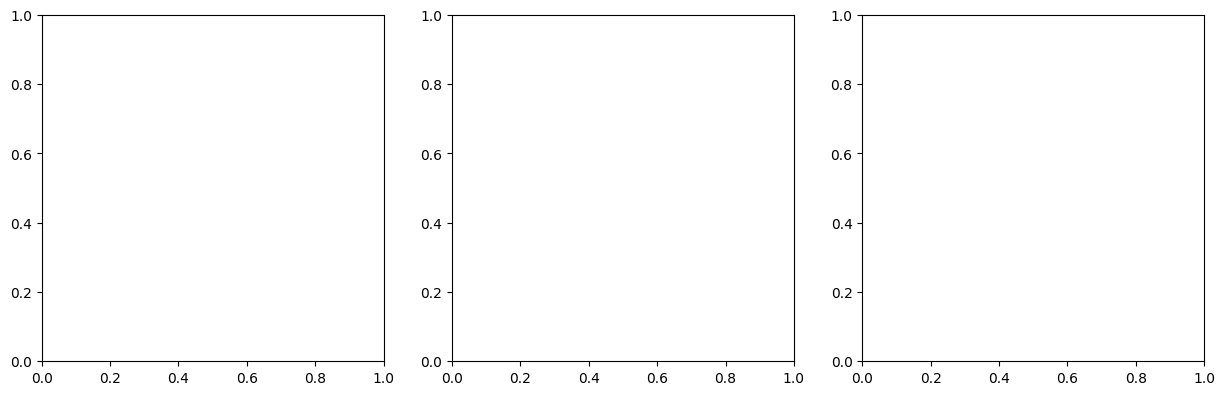

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metrics = [user_activity_mean	
    ("du_mean", r"Mean $d_u$", "User degree"),
    ("di_mean", r"Mean $d_i$", "Item degree"),
    ("q_mean", r"Mean $q_{ui}$", "Niche score"),
]

for ax, (column, ylabel, title) in zip(axes, metrics):
    ax.bar(
        band_summary.index.astype(str),
        band_summary[column],
        color=["firebrick", "darkorange", "gold", "steelblue"],
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Structural properties across mask-tail bands")
plt.tight_layout()
plt.show()

In [ ]:
def categorical_tail_enrichment(data, category_column):
    baseline = (
        data[category_column]
        .value_counts(normalize=True)
    )

    rows = []

    for tail_label, (tail_column, _) in tail_definitions.items():
        selected = data[data[tail_column]]
        remaining = data[~data[tail_column]]

        selected_counts = selected[category_column].value_counts()
        selected_share = selected[category_column].value_counts(
            normalize=True
        )
        remaining_share = remaining[category_column].value_counts(
            normalize=True
        )

        categories = baseline.index.union(selected_share.index)

        for category in categories:
            tail_share = selected_share.get(category, 0.0)
            rest_share = remaining_share.get(category, 0.0)
            baseline_share = baseline.get(category, 0.0)

            rows.append({
                "tail": tail_label,
                "category": category,
                "tail_count": selected_counts.get(category, 0),
                "tail_share": tail_share,
                "rest_share": rest_share,
                "overall_share": baseline_share,
                "lift_vs_overall": (
                    tail_share / baseline_share
                    if baseline_share > 0 else np.nan
                ),
                "lift_vs_rest": (
                    tail_share / rest_share
                    if rest_share > 0 else np.inf
                ),
            })

    return pd.DataFrame(rows)


degree_enrichment = categorical_tail_enrichment(
    analysis,
    "degree_group",
)

degree_share_table = degree_enrichment.pivot(
    index="tail",
    columns="category",
    values="tail_share",
).reindex(
    index=tail_definitions.keys(),
    columns=degree_group_order,
)

degree_lift_table = degree_enrichment.pivot(
    index="tail",
    columns="category",
    values="lift_vs_overall",
).reindex(
    index=tail_definitions.keys(),
    columns=degree_group_order,
)

print("Fraction of each bottom-mask subset:")
display(degree_share_table.round(4))

print("Enrichment relative to the complete graph:")
display(degree_lift_table.round(4))

Fraction of each bottom-mask subset:


category,mainstream (high/high),niche (high/low),popular exposure (low/high),sparse (low/low)
tail,,,,
Bottom 1%,0.7170,0.1710,0.0913,0.0207
Bottom 5%,0.7075,0.1770,0.0936,0.0219
Bottom 10%,0.6954,0.1744,0.1058,0.0243


Enrichment relative to the complete graph:


category,mainstream (high/high),niche (high/low),popular exposure (low/high),sparse (low/low)
tail,,,,
Bottom 1%,1.1053,0.9993,0.6252,0.6062
Bottom 5%,1.0907,1.0344,0.6412,0.6402
Bottom 10%,1.0721,1.0195,0.7248,0.7106


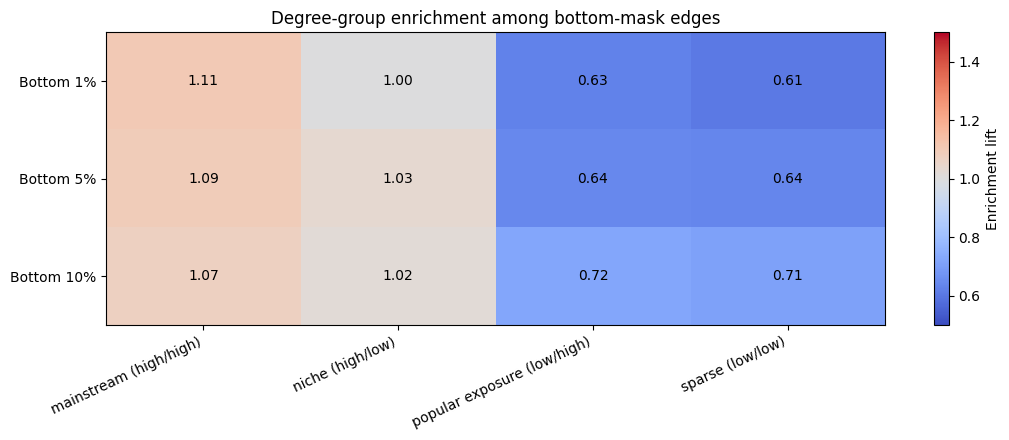

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))

values = degree_lift_table.to_numpy(dtype=float)

image = ax.imshow(
    values,
    cmap="coolwarm",
    aspect="auto",
    vmin=0.5,
    vmax=max(1.5, np.nanmax(values)),
)

ax.set_xticks(np.arange(len(degree_lift_table.columns)))
ax.set_xticklabels(
    degree_lift_table.columns,
    rotation=25,
    ha="right",
)

ax.set_yticks(np.arange(len(degree_lift_table.index)))
ax.set_yticklabels(degree_lift_table.index)

for row in range(values.shape[0]):
    for column in range(values.shape[1]):
        ax.text(
            column,
            row,
            f"{values[row, column]:.2f}",
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(image, ax=ax, label="Enrichment lift")
ax.set_title("Degree-group enrichment among bottom-mask edges")

plt.tight_layout()
plt.show()

In [20]:
user_nodes = (
    analysis[[USER_COL, "user_degree"]]
    .drop_duplicates(USER_COL)
    .copy()
)

item_nodes = (
    analysis[[ITEM_COL, "item_degree"]]
    .drop_duplicates(ITEM_COL)
    .copy()
)

user_percentile = user_nodes["user_degree"].rank(
    method="average",
    pct=True,
)

item_percentile = item_nodes["item_degree"].rank(
    method="average",
    pct=True,
)

user_nodes["user_activity_decile"] = np.clip(
    np.ceil(user_percentile * 10),
    1,
    10,
).astype(int)

item_nodes["item_popularity_decile"] = np.clip(
    np.ceil(item_percentile * 10),
    1,
    10,
).astype(int)

user_decile_map = user_nodes.set_index(
    USER_COL
)["user_activity_decile"]

item_decile_map = item_nodes.set_index(
    ITEM_COL
)["item_popularity_decile"]

analysis["user_activity_decile"] = (
    analysis[USER_COL].map(user_decile_map)
)

analysis["item_popularity_decile"] = (
    analysis[ITEM_COL].map(item_decile_map)
)

user_decile_enrichment = categorical_tail_enrichment(
    analysis,
    "user_activity_decile",
)

item_decile_enrichment = categorical_tail_enrichment(
    analysis,
    "item_popularity_decile",
)


def enrichment_pivot(enrichment):
    return enrichment.pivot(
        index="tail",
        columns="category",
        values="lift_vs_overall",
    ).reindex(
        index=tail_definitions.keys(),
        columns=range(1, 11),
    )


user_decile_lift = enrichment_pivot(user_decile_enrichment)
item_decile_lift = enrichment_pivot(item_decile_enrichment)

print("User-activity decile enrichment:")
display(user_decile_lift.round(3))

print("Item-popularity decile enrichment:")
display(item_decile_lift.round(3))

NameError: name 'categorical_tail_enrichment' is not defined

In [21]:
def entity_concentration(data, subset_flag, entity_column):
    all_entities = pd.Index(data[entity_column].unique())

    counts = (
        data.loc[subset_flag, entity_column]
        .value_counts()
        .reindex(all_entities, fill_value=0)
    )

    total = counts.sum()
    positive_counts = counts[counts > 0]

    if total == 0:
        return {
            "coverage": 0,
            "top_1pct_edge_share": np.nan,
            "HHI": np.nan,
        }

    # Top 1% is defined relative to all active entities.
    top_k = max(1, int(np.ceil(0.01 * len(all_entities))))

    probabilities = positive_counts / total

    return {
        "entities_present": len(positive_counts),
        "total_active_entities": len(all_entities),
        "coverage": len(positive_counts) / len(all_entities),
        "top_1pct_edge_share": (
            counts.nlargest(top_k).sum() / total
        ),
        "HHI": np.square(probabilities).sum(),
    }


concentration_rows = []

# Complete-graph baseline
for entity_column, entity_type in [
    (USER_COL, "user"),
    (ITEM_COL, "item"),
]:
    result = entity_concentration(
        analysis,
        np.ones(len(analysis), dtype=bool),
        entity_column,
    )

    concentration_rows.append({
        "subset": "Complete graph",
        "entity_type": entity_type,
        **result,
    })

for tail_label, (tail_column, _) in tail_definitions.items():
    for entity_column, entity_type in [
        (USER_COL, "user"),
        (ITEM_COL, "item"),
    ]:
        result = entity_concentration(
            analysis,
            analysis[tail_column],
            entity_column,
        )

        concentration_rows.append({
            "subset": tail_label,
            "entity_type": entity_type,
            **result,
        })

concentration_table = pd.DataFrame(concentration_rows)

display(
    concentration_table.set_index(
        ["subset", "entity_type"]
    ).round(6)
)

entities_present  total_active_entities  coverage  \
subset         entity_type                                                      
Complete graph user                    11000                  11000  1.000000   
               item                     9332                   9332  1.000000   
Bottom 1%      user                      718                  11000  0.065273   
               item                     1085                   9332  0.116267   
Bottom 5%      user                     2323                  11000  0.211182   
               item                     3920                   9332  0.420060   
Bottom 10%     user                     3938                  11000  0.358000   
               item                     5945                   9332  0.637055   

                            top_1pct_edge_share       HHI  
subset         entity_type                                 
Complete graph user                    0.091745  0.000228  
               item                    0.075301  0.000208  
Bottom 1%      user                    0.417427  0.003221  
               item                    0.167635  0.001017  
Bottom 5%      user                    0.295817  0.001407  
               item                    0.097942  0.000376  
Bottom 10%     user                    0.236739  0.000928  
               item                    0.089234  0.000296

In [22]:
def entity_tail_report(
    data,
    entity_column,
    tail_column,
    minimum_edges=10,
):
    total = data.groupby(entity_column).size().rename("total_edges")

    tail = (
        data[data[tail_column]]
        .groupby(entity_column)
        .size()
        .rename("tail_edges")
    )

    report = pd.concat([total, tail], axis=1).fillna(0)
    report["tail_edges"] = report["tail_edges"].astype(int)
    report["tail_rate"] = (
        report["tail_edges"] / report["total_edges"]
    )

    expected_rate = data[tail_column].mean()
    report["tail_lift"] = report["tail_rate"] / expected_rate

    return (
        report[report["total_edges"] >= minimum_edges]
        .sort_values(
            ["tail_lift", "tail_edges"],
            ascending=False,
        )
    )


bottom_10_users = entity_tail_report(
    analysis,
    USER_COL,
    "bottom_10",
    minimum_edges=10,
)

bottom_10_items = entity_tail_report(
    analysis,
    ITEM_COL,
    "bottom_10",
    minimum_edges=10,
)

print("Users most enriched in bottom-10% mask edges:")
display(bottom_10_users.head(20).round(4))

print("Items most enriched in bottom-10% mask edges:")
display(bottom_10_items.head(20).round(4))

Users most enriched in bottom-10% mask edges:


,total_edges,tail_edges,tail_rate,tail_lift
userID,,,,
738,13,13,1.0000,9.9995
748,13,13,1.0000,9.9995
4727,13,13,1.0000,9.9995
772,11,11,1.0000,9.9995
7513,10,10,1.0000,9.9995
706,24,23,0.9583,9.5829
739,23,22,0.9565,9.5647
736,21,20,0.9524,9.5233
6321,20,19,0.9500,9.4995


Items most enriched in bottom-10% mask edges:


,total_edges,tail_edges,tail_rate,tail_lift
itemID,,,,
5705,16,10,0.6250,6.2497
1390,14,7,0.5000,4.9998
4433,12,6,0.5000,4.9998
7142,10,5,0.5000,4.9998
3716,13,6,0.4615,4.6152
1399,22,10,0.4545,4.5452
4453,23,10,0.4348,4.3476
4000,14,6,0.4286,4.2855
49,12,5,0.4167,4.1665


In [23]:
from pathlib import Path
from sklearn.cluster import MiniBatchKMeans

text_feature_path = Path(
    r"C:\study\Master_papers\Robust MM"
    r"\CaMuRe\data\book\text_feat.npy"
)

text_features = np.load(text_feature_path).astype(np.float32)

if text_features.shape[0] <= analysis[ITEM_COL].max():
    raise ValueError(
        "Text-feature rows do not cover all item IDs."
    )

active_item_ids = np.sort(analysis[ITEM_COL].unique())
active_features = text_features[active_item_ids]

# L2 normalization before content clustering
feature_norm = np.linalg.norm(
    active_features,
    axis=1,
    keepdims=True,
)
active_features = active_features / np.maximum(feature_norm, 1e-12)

n_domains = 20

cluster_model = MiniBatchKMeans(
    n_clusters=n_domains,
    random_state=999,
    batch_size=4096,
    n_init=10,
)

active_domain_labels = cluster_model.fit_predict(active_features)

item_to_domain = pd.Series(
    active_domain_labels,
    index=active_item_ids,
)

analysis["content_domain"] = (
    analysis[ITEM_COL].map(item_to_domain)
)

domain_enrichment = categorical_tail_enrichment(
    analysis,
    "content_domain",
)

bottom_10_domains = (
    domain_enrichment[
        domain_enrichment["tail"] == "Bottom 10%"
    ]
    .sort_values("lift_vs_overall", ascending=False)
)

display(bottom_10_domains.round(4))

NameError: name 'categorical_tail_enrichment' is not defined

In [ ]:
bottom_10 = analysis[analysis["bottom_10"]]
rest_90 = analysis[~analysis["bottom_10"]]

most_enriched_group = (
    degree_enrichment[
        degree_enrichment["tail"] == "Bottom 10%"
    ]
    .sort_values("lift_vs_overall", ascending=False)
    .iloc[0]
)

most_enriched_user_decile = (
    user_decile_enrichment[
        user_decile_enrichment["tail"] == "Bottom 10%"
    ]
    .sort_values("lift_vs_overall", ascending=False)
    .iloc[0]
)

most_enriched_item_decile = (
    item_decile_enrichment[
        item_decile_enrichment["tail"] == "Bottom 10%"
    ]
    .sort_values("lift_vs_overall", ascending=False)
    .iloc[0]
)

print("BOTTOM-10% MASK DIAGNOSIS")
print("-" * 50)

print(
    f"Mean user degree: "
    f"{bottom_10['du'].mean():.4f} in tail vs "
    f"{rest_90['du'].mean():.4f} in rest"
)

print(
    f"Mean item degree: "
    f"{bottom_10['di'].mean():.4f} in tail vs "
    f"{rest_90['di'].mean():.4f} in rest"
)

print(
    f"Mean niche score: "
    f"{bottom_10['q_ui'].mean():.4f} in tail vs "
    f"{rest_90['q_ui'].mean():.4f} in rest"
)

print(
    f"Most enriched degree group: "
    f"{most_enriched_group['category']} "
    f"(lift={most_enriched_group['lift_vs_overall']:.3f})"
)

print(
    f"Most enriched user-activity decile: "
    f"{int(most_enriched_user_decile['category'])} "
    f"(lift={most_enriched_user_decile['lift_vs_overall']:.3f})"
)

print(
    f"Most enriched item-popularity decile: "
    f"{int(most_enriched_item_decile['category'])} "
    f"(lift={most_enriched_item_decile['lift_vs_overall']:.3f})"
)

BOTTOM-10% MASK DIAGNOSIS
--------------------------------------------------
Mean user degree: 0.5053 in tail vs 0.4479 in rest
Mean item degree: 0.4612 in tail vs 0.4586 in rest
Mean niche score: 0.2737 in tail vs 0.2444 in rest
Most enriched degree group: mainstream (high/high) (lift=1.072)
Most enriched user-activity decile: 10 (lift=1.307)
Most enriched item-popularity decile: 1 (lift=1.057)


In [ ]:
N_USER_BINS = 10
N_ITEM_BINS = 10


def assign_degree_bins(data, id_column, degree_column, n_bins):
    nodes = (
        data[[id_column, degree_column]]
        .drop_duplicates(id_column)
        .copy()
    )

    nodes["degree_bin"] = pd.qcut(
        nodes[degree_column].rank(method="first"),
        q=n_bins,
        labels=range(1, n_bins + 1),
    ).astype(int)

    return nodes.set_index(id_column)["degree_bin"]


user_bin_map = assign_degree_bins(
    analysis,
    USER_COL,
    "user_degree",
    N_USER_BINS,
)

item_bin_map = assign_degree_bins(
    analysis,
    ITEM_COL,
    "item_degree",
    N_ITEM_BINS,
)

analysis["user_degree_bin"] = analysis[USER_COL].map(user_bin_map)
analysis["item_degree_bin"] = analysis[ITEM_COL].map(item_bin_map)

In [ ]:
user_bin_summary = (
    analysis.groupby("user_degree_bin", observed=True)
    .agg(
        n_users=(USER_COL, "nunique"),
        n_edges=("mask", "size"),
        mean_degree=("user_degree", "mean"),
        mean_mask=("mask", "mean"),
        median_mask=("mask", "median"),
    )
    .reindex(range(1, N_USER_BINS + 1))
)

item_bin_summary = (
    analysis.groupby("item_degree_bin", observed=True)
    .agg(
        n_items=(ITEM_COL, "nunique"),
        n_edges=("mask", "size"),
        mean_degree=("item_degree", "mean"),
        mean_mask=("mask", "mean"),
        median_mask=("mask", "median"),
    )
    .reindex(range(1, N_ITEM_BINS + 1))
)

display(user_bin_summary.round(6))
display(item_bin_summary.round(6))

,n_users,n_edges,mean_degree,mean_mask,median_mask
user_degree_bin,,,,,
1,1100,2672,2.638473,0.957621,0.977496
2,1100,4325,3.947977,0.954897,0.977190
3,1100,5428,4.946942,0.954016,0.976892
4,1100,6269,5.736003,0.954555,0.976689
5,1100,7197,6.580659,0.955070,0.976996
6,1100,8310,7.587244,0.957711,0.977852
7,1100,9955,9.098041,0.955964,0.977247
8,1100,12643,11.579926,0.951238,0.976263
9,1100,18325,16.952306,0.947173,0.976215


,n_items,n_edges,mean_degree,mean_mask,median_mask
item_degree_bin,,,,,
1,934,4078,4.509564,0.945210,0.975007
2,933,5603,6.023737,0.948192,0.976299
3,933,6531,7.000000,0.948511,0.975801
4,933,7343,7.884652,0.947525,0.976061
5,933,8250,8.857455,0.946079,0.975774
6,933,9327,10.023695,0.947653,0.976170
7,933,10895,11.716108,0.948911,0.976166
8,933,13292,14.316130,0.946873,0.975695
9,933,17588,19.055606,0.947553,0.976324


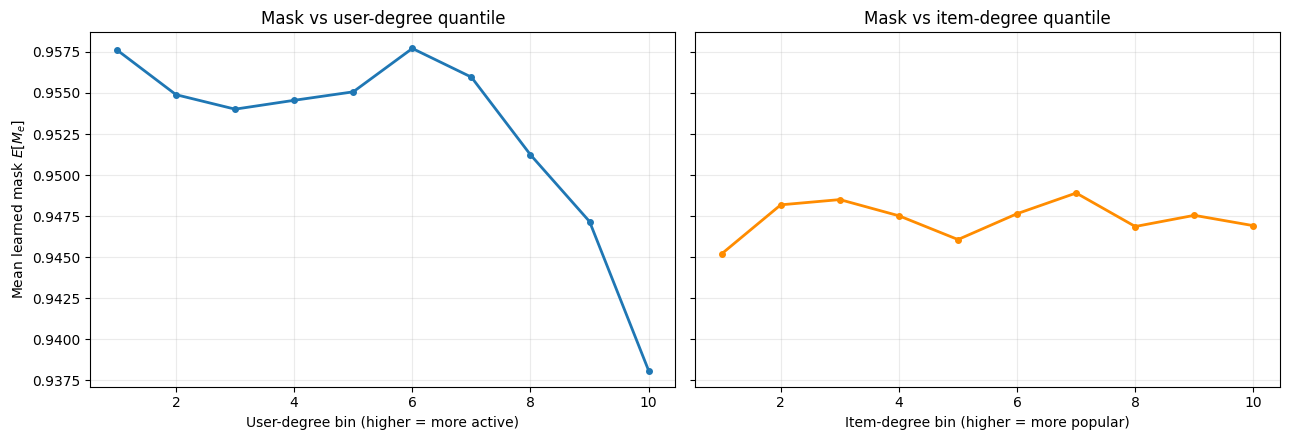

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].plot(
    user_bin_summary.index,
    user_bin_summary["mean_mask"],
    marker="o",
    markersize=4,
    linewidth=2,
)
axes[0].set_title("Mask vs user-degree quantile")
axes[0].set_xlabel("User-degree bin (higher = more active)")
axes[0].set_ylabel(r"Mean learned mask $E[M_e]$")
axes[0].grid(alpha=0.25)

axes[1].plot(
    item_bin_summary.index,
    item_bin_summary["mean_mask"],
    marker="o",
    markersize=4,
    linewidth=2,
    color="darkorange",
)
axes[1].set_title("Mask vs item-degree quantile")
axes[1].set_xlabel("Item-degree bin (higher = more popular)")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

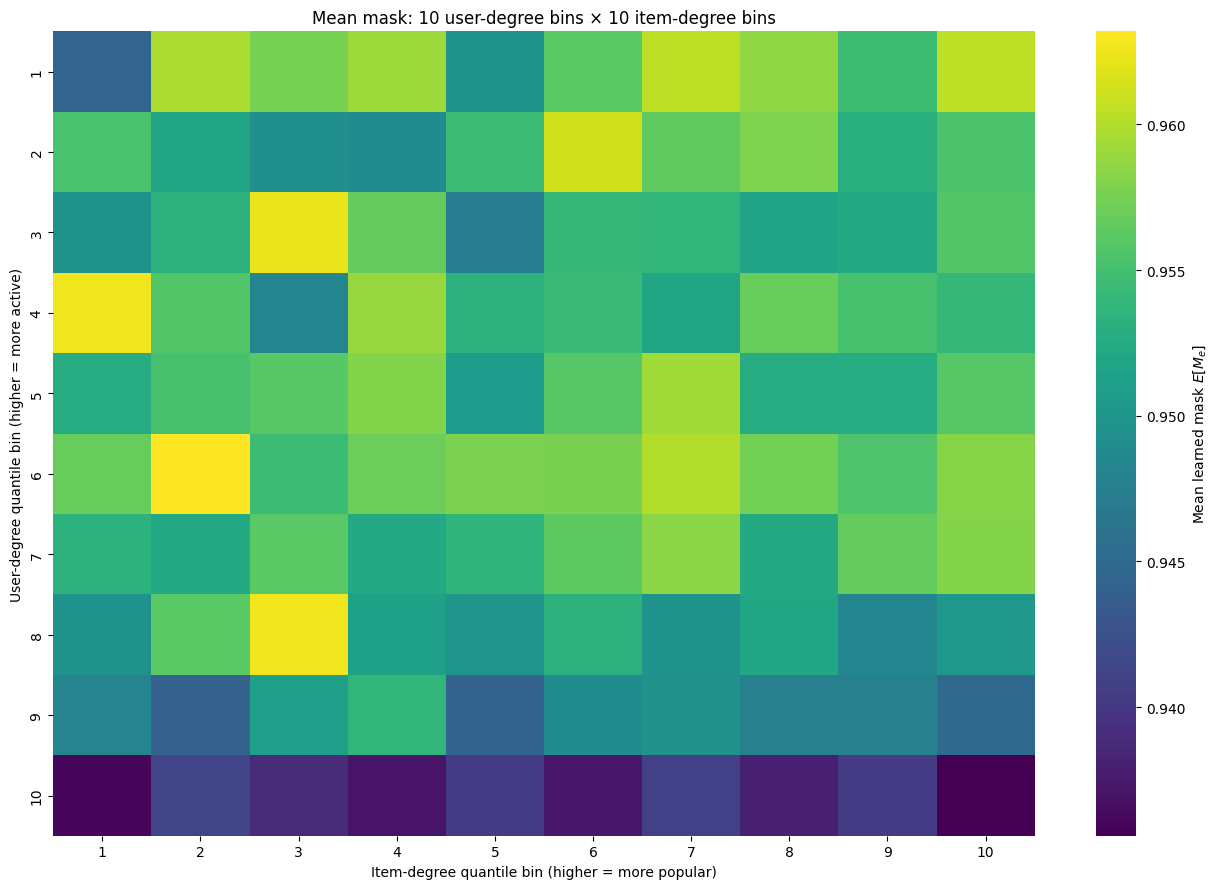

In [ ]:
mean_mask_heatmap = (
    analysis.pivot_table(
        index="user_degree_bin",
        columns="item_degree_bin",
        values="mask",
        aggfunc="mean",
    )
    .reindex(
        index=range(1, N_USER_BINS + 1),
        columns=range(1, N_ITEM_BINS + 1),
    )
)

edge_count_heatmap = (
    analysis.pivot_table(
        index="user_degree_bin",
        columns="item_degree_bin",
        values="mask",
        aggfunc="size",
        fill_value=0,
    )
    .reindex(
        index=range(1, N_USER_BINS + 1),
        columns=range(1, N_ITEM_BINS + 1),
        fill_value=0,
    )
)

# Hide unreliable cells with too few interactions.
MIN_EDGES_PER_CELL = 20
plot_heatmap = mean_mask_heatmap.mask(
    edge_count_heatmap < MIN_EDGES_PER_CELL
)

plt.figure(figsize=(13, 9))

sns.heatmap(
    plot_heatmap,
    cmap="viridis",
    annot=False,  # annotations become crowded with 20×20 bins
    cbar_kws={"label": r"Mean learned mask $E[M_e]$"},
)

plt.xlabel("Item-degree quantile bin (higher = more popular)")
plt.ylabel("User-degree quantile bin (higher = more active)")
plt.title(
    f"Mean mask: {N_USER_BINS} user-degree bins × "
    f"{N_ITEM_BINS} item-degree bins"
)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

USER_COL = "userID"
analysis = edge_analysis.copy()


# ================================================================
# 1. Effective degree and retention ratio for every user
# ================================================================
user_retention = (
    analysis.groupby(USER_COL)
    .agg(
        original_degree=("mask", "size"),
        effective_degree=("mask", "sum"),
        retention_ratio=("mask", "mean"),
    )
    .reset_index()
)

# Sanity check: d_u^M / d_u must equal mean mask.
assert np.allclose(
    user_retention["effective_degree"]
    / user_retention["original_degree"],
    user_retention["retention_ratio"],
)

display(user_retention.head())

,userID,original_degree,effective_degree,retention_ratio
0,0,3,2.887425,0.962475
1,1,28,26.862958,0.959391
2,2,21,20.504254,0.976393
3,3,26,24.956646,0.959871
4,4,27,25.977674,0.962136


In [ ]:
degree = user_retention["original_degree"].to_numpy(dtype=float)
retention = user_retention["retention_ratio"].to_numpy(dtype=float)

pearson_r, pearson_p = pearsonr(degree, retention)
log_pearson_r, log_pearson_p = pearsonr(
    np.log1p(degree),
    retention,
)
spearman_rho, spearman_p = spearmanr(degree, retention)

correlation_summary = pd.Series({
    "Pearson r (raw degree)": pearson_r,
    "Pearson p (raw degree)": pearson_p,
    "Pearson r (log degree)": log_pearson_r,
    "Pearson p (log degree)": log_pearson_p,
    "Spearman rho": spearman_rho,
    "Spearman p": spearman_p,
})

display(correlation_summary.to_frame("value"))

,value
Pearson r (raw degree),-9.982570e-02
Pearson p (raw degree),9.123209e-26
Pearson r (log degree),-1.003240e-01
Pearson p (log degree),5.217162e-26
Spearman rho,-1.909171e-01
Spearman p,8.424905e-91


In [ ]:
N_BINS = 10

# Assign approximately equal numbers of users to each bin.
user_retention["degree_bin"] = pd.qcut(
    user_retention["original_degree"].rank(method="first"),
    q=N_BINS,
    labels=range(1, N_BINS + 1),
).astype(int)

retention_by_degree = (
    user_retention.groupby("degree_bin", observed=True)
    .agg(
        n_users=(USER_COL, "size"),
        minimum_degree=("original_degree", "min"),
        median_degree=("original_degree", "median"),
        maximum_degree=("original_degree", "max"),
        mean_effective_degree=("effective_degree", "mean"),
        mean_retention=("retention_ratio", "mean"),
        median_retention=("retention_ratio", "median"),
        retention_std=("retention_ratio", "std"),
    )
    .reindex(range(1, N_BINS + 1))
)

retention_by_degree["retention_sem"] = (
    retention_by_degree["retention_std"]
    / np.sqrt(retention_by_degree["n_users"])
)

display(retention_by_degree.round(6))

,n_users,minimum_degree,median_degree,maximum_degree,mean_effective_degree,mean_retention,median_retention,retention_std,retention_sem
degree_bin,,,,,,,,,
1,1100,1,3.0,3,2.326149,0.957504,0.974691,0.054630,0.001647
2,1100,3,4.0,4,3.754482,0.954886,0.972366,0.048414,0.001460
3,1100,4,5.0,5,4.707633,0.953946,0.971053,0.050020,0.001508
4,1100,5,6.0,6,5.440094,0.954805,0.969492,0.046963,0.001416
5,1100,6,7.0,7,6.248764,0.955495,0.970553,0.044675,0.001347
6,1100,7,8.0,8,7.235075,0.958020,0.971770,0.039936,0.001204
7,1100,8,9.0,10,8.651478,0.956177,0.969695,0.038203,0.001152
8,1100,10,11.0,13,10.933178,0.951609,0.966889,0.046559,0.001404
9,1100,13,16.0,21,15.779049,0.947746,0.964861,0.048988,0.001477


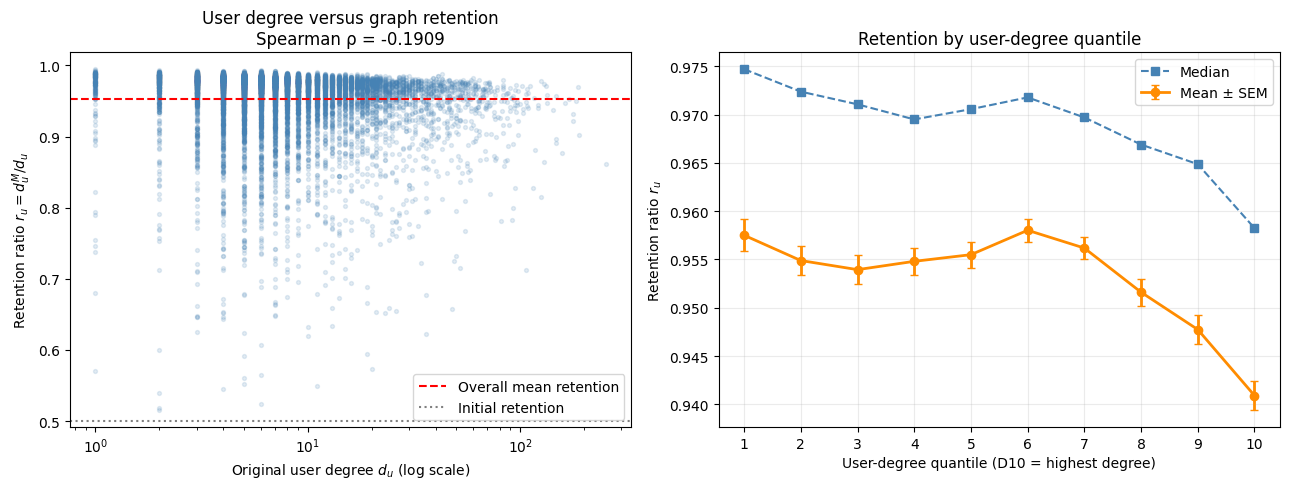

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sample only for rendering; calculations above use all users.
plot_users = user_retention.sample(
    n=min(50_000, len(user_retention)),
    random_state=999,
)

axes[0].scatter(
    plot_users["original_degree"],
    plot_users["retention_ratio"],
    s=8,
    alpha=0.15,
    color="steelblue",
)

axes[0].axhline(
    user_retention["retention_ratio"].mean(),
    color="red",
    linestyle="--",
    label="Overall mean retention",
)

axes[0].axhline(
    0.5,
    color="gray",
    linestyle=":",
    label="Initial retention",
)

axes[0].set_xscale("log")
axes[0].set_xlabel(r"Original user degree $d_u$ (log scale)")
axes[0].set_ylabel(r"Retention ratio $r_u=d_u^M/d_u$")
axes[0].set_title(
    "User degree versus graph retention\n"
    f"Spearman ρ = {spearman_rho:.4f}"
)
axes[0].legend()

# Quantile-level trend
axes[1].errorbar(
    retention_by_degree.index,
    retention_by_degree["mean_retention"],
    yerr=retention_by_degree["retention_sem"],
    marker="o",
    linewidth=2,
    capsize=3,
    color="darkorange",
    label="Mean ± SEM",
)

axes[1].plot(
    retention_by_degree.index,
    retention_by_degree["median_retention"],
    marker="s",
    linestyle="--",
    color="steelblue",
    label="Median",
)

axes[1].set_xticks(range(1, N_BINS + 1))
axes[1].set_xlabel("User-degree quantile (D10 = highest degree)")
axes[1].set_ylabel(r"Retention ratio $r_u$")
axes[1].set_title("Retention by user-degree quantile")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
top_degree_threshold = user_retention["original_degree"].quantile(0.90)

top_users = user_retention[
    user_retention["original_degree"] >= top_degree_threshold
]

other_users = user_retention[
    user_retention["original_degree"] < top_degree_threshold
]

top_comparison = pd.Series({
    "Top-degree threshold": top_degree_threshold,
    "Top 10% mean retention": top_users["retention_ratio"].mean(),
    "Other 90% mean retention": other_users["retention_ratio"].mean(),
    "Top minus other mean": (
        top_users["retention_ratio"].mean()
        - other_users["retention_ratio"].mean()
    ),
    "D10 minus D1 mean": (
        retention_by_degree.loc[10, "mean_retention"]
        - retention_by_degree.loc[1, "mean_retention"]
    ),
})

display(top_comparison.to_frame("value").round(6))

,value
Top-degree threshold,21.000000
Top 10% mean retention,0.940091
Other 90% mean retention,0.954637
Top minus other mean,-0.014546
D10 minus D1 mean,-0.016586


In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import wilcoxon

USER_COL = "userID"
ITEM_COL = "itemID"

analysis = edge_analysis.copy().reset_index(drop=True)

# Degree và decile được xác định ở cấp user.
user_table = (
    analysis.groupby(USER_COL)
    .size()
    .rename("original_degree")
    .reset_index()
)

user_table["degree_decile"] = pd.qcut(
    user_table["original_degree"].rank(method="first"),
    q=10,
    labels=range(1, 11),
).astype(int)

analysis = analysis.merge(
    user_table,
    on=USER_COL,
    how="left",
    validate="many_to_one",
)

# Chỉ lấy D9 và D10.
hub_edges = analysis[
    analysis["degree_decile"].isin([9, 10])
].copy()

# Xếp hạng mask riêng bên trong mỗi user.
hub_edges["within_user_mask_rank"] = (
    hub_edges.groupby(USER_COL)["mask"]
    .rank(method="first", ascending=True)
)

hub_edges["tail_size"] = np.ceil(
    0.10 * hub_edges["original_degree"]
).astype(int)

hub_edges["mask_tail"] = "middle"

hub_edges.loc[
    hub_edges["within_user_mask_rank"]
    <= hub_edges["tail_size"],
    "mask_tail",
] = "bottom 10%"

hub_edges.loc[
    hub_edges["within_user_mask_rank"]
    > (
        hub_edges["original_degree"]
        - hub_edges["tail_size"]
    ),
    "mask_tail",
] = "top 10%"

selected = hub_edges[
    hub_edges["mask_tail"].isin(["bottom 10%", "top 10%"])
].copy()

print(f"D9/D10 users: {selected[USER_COL].nunique():,}")
print(f"Selected edges: {len(selected):,}")

display(
    selected.groupby("mask_tail")["mask"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(6)
)

D9/D10 users: 2,200
Selected edges: 14,688


,count,mean,median,min,max
mask_tail,,,,,
bottom 10%,7344,0.789581,0.873923,0.024416,0.985325
top 10%,7344,0.987879,0.989949,0.829445,0.996986


In [25]:
interaction_path = Path(
    r"C:\study\Master_papers\Robust MM"
    r"\CaMuRe\data\book\book.inter"
)

TIME_COL = "timestamp"

raw_interactions = pd.read_csv(
    interaction_path,
    sep="\t",
    usecols=[USER_COL, ITEM_COL, TIME_COL, "x_label"],
)

train_rows = (
    raw_interactions[raw_interactions["x_label"] == 0]
    .reset_index(drop=True)
)

# Mask và interaction phải có cùng thứ tự.
aligned = (
    len(train_rows) == len(analysis)
    and np.array_equal(
        train_rows[USER_COL].to_numpy(),
        analysis[USER_COL].to_numpy(),
    )
    and np.array_equal(
        train_rows[ITEM_COL].to_numpy(),
        analysis[ITEM_COL].to_numpy(),
    )
)

if not aligned:
    raise ValueError(
        "edge_analysis không cùng thứ tự với training interactions."
    )

analysis[TIME_COL] = train_rows[TIME_COL].to_numpy()

analysis["recency_percentile"] = (
    analysis.groupby(USER_COL)[TIME_COL]
    .rank(method="average", pct=True)
)

# Popularity sử dụng log item degree vì degree thường lệch mạnh.
analysis["log_item_degree"] = np.log1p(
    analysis["item_degree"]
)

user_logpop_sum = (
    analysis.groupby(USER_COL)["log_item_degree"]
    .transform("sum")
)

other_history_size = analysis["original_degree"] - 1

analysis["history_mean_log_item_degree"] = (
    user_logpop_sum - analysis["log_item_degree"]
) / other_history_size

# Âm: item kém phổ biến hơn lịch sử thông thường của user.
# Dương: item phổ biến hơn lịch sử thông thường của user.
analysis["popularity_deviation"] = (
    analysis["log_item_degree"]
    - analysis["history_mean_log_item_degree"]
)

analysis["absolute_popularity_deviation"] = (
    analysis["popularity_deviation"].abs()
)

selected = selected.drop(
    columns=[
        TIME_COL,
        "recency_percentile",
        "log_item_degree",
        "history_mean_log_item_degree",
        "popularity_deviation",
        "absolute_popularity_deviation",
    ],
    errors="ignore",
).merge(
    analysis[
        [
            USER_COL,
            ITEM_COL,
            "mask",
            TIME_COL,
            "recency_percentile",
            "log_item_degree",
            "popularity_deviation",
            "absolute_popularity_deviation",
        ]
    ],
    on=[USER_COL, ITEM_COL, "mask"],
    how="left",
    validate="one_to_one",
)

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

USER_COL = "userID"

required_columns = {
    USER_COL,
    "degree_decile",
    "mask_tail",
    "recency_percentile",
    "popularity_deviation",
    "absolute_popularity_deviation",
}

missing = required_columns - set(selected.columns)

if missing:
    raise ValueError(f"selected thiếu các cột: {sorted(missing)}")


plot_metrics = {
    "recency_percentile": "Recency percentile",
    "popularity_deviation": "Signed popularity deviation",
    "absolute_popularity_deviation": "Absolute popularity deviation",
}

difference_frames = []

for metric, label in plot_metrics.items():
    bottom = (
        selected[selected["mask_tail"] == "bottom 10%"]
        .groupby([USER_COL, "degree_decile"])[metric]
        .mean()
        .rename("bottom")
    )

    top = (
        selected[selected["mask_tail"] == "top 10%"]
        .groupby([USER_COL, "degree_decile"])[metric]
        .mean()
        .rename("top")
    )

    paired_metric = (
        pd.concat([bottom, top], axis=1)
        .dropna()
        .reset_index()
    )

    paired_metric["difference"] = (
        paired_metric["bottom"] - paired_metric["top"]
    )

    paired_metric["metric"] = label
    difference_frames.append(paired_metric)

difference_plot_data = pd.concat(
    difference_frames,
    ignore_index=True,
)

In [27]:
text_feature_path = Path(
    r"C:\study\Master_papers\Robust MM"
    r"\CaMuRe\data\book\text_feat.npy"
)

text_features = np.load(text_feature_path).astype(np.float32)

# Chuẩn hóa item embedding.
text_norm = np.linalg.norm(
    text_features,
    axis=1,
    keepdims=True,
)

text_features = text_features / np.maximum(text_norm, 1e-12)

all_user_ids = analysis[USER_COL].to_numpy(dtype=np.int64)
all_item_ids = analysis[ITEM_COL].to_numpy(dtype=np.int64)

num_users = int(all_user_ids.max()) + 1
embedding_dim = text_features.shape[1]

# Tổng embedding lịch sử của từng user.
user_history_sum = np.zeros(
    (num_users, embedding_dim),
    dtype=np.float32,
)

np.add.at(
    user_history_sum,
    all_user_ids,
    text_features[all_item_ids],
)

selected_users = selected[USER_COL].to_numpy(dtype=np.int64)
selected_items = selected[ITEM_COL].to_numpy(dtype=np.int64)

current_item_vectors = text_features[selected_items]

# Leave-one-out history representation.
other_history_vectors = (
    user_history_sum[selected_users]
    - current_item_vectors
)

other_history_norm = np.linalg.norm(
    other_history_vectors,
    axis=1,
)

selected["history_content_similarity"] = (
    np.einsum(
        "ij,ij->i",
        current_item_vectors,
        other_history_vectors,
    )
    / np.maximum(other_history_norm, 1e-12)
)

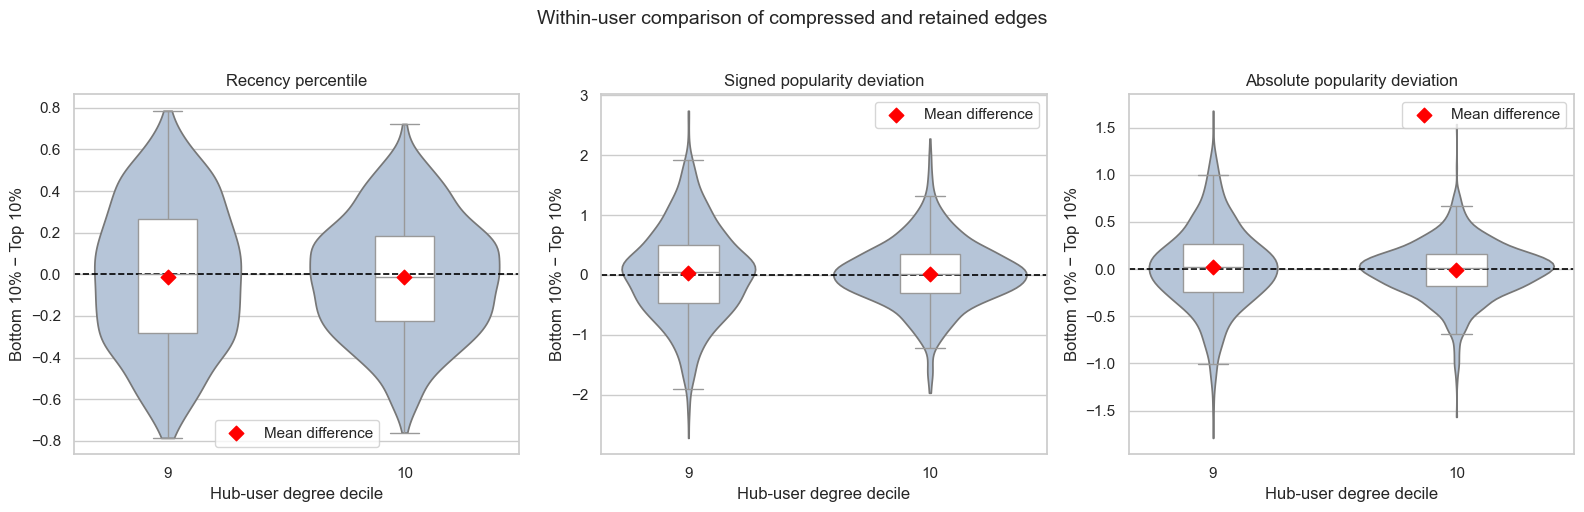

In [28]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

for ax, (metric, label) in zip(
    axes,
    plot_metrics.items(),
):
    metric_data = difference_plot_data[
        difference_plot_data["metric"] == label
    ]

    sns.violinplot(
        data=metric_data,
        x="degree_decile",
        y="difference",
        inner=None,
        cut=0,
        color="lightsteelblue",
        ax=ax,
    )

    sns.boxplot(
        data=metric_data,
        x="degree_decile",
        y="difference",
        width=0.25,
        showfliers=False,
        color="white",
        ax=ax,
    )

    # Thêm mean bằng điểm đỏ.
    mean_difference = (
        metric_data.groupby("degree_decile")["difference"]
        .mean()
        .reindex([9, 10])
    )

    ax.scatter(
        range(len(mean_difference)),
        mean_difference,
        color="red",
        marker="D",
        s=55,
        zorder=5,
        label="Mean difference",
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.set_xlabel("Hub-user degree decile")
    ax.set_ylabel("Bottom 10% − Top 10%")
    ax.set_title(label)
    ax.legend()

plt.suptitle(
    "Within-user comparison of compressed and retained edges",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.show()

In [29]:
all_users = analysis[USER_COL].to_numpy(dtype=np.int64)
all_items = analysis[ITEM_COL].to_numpy(dtype=np.int64)

num_users = int(all_users.max()) + 1
num_items = int(all_items.max()) + 1

adjacency = sp.coo_matrix(
    (
        np.ones(len(analysis), dtype=np.int64),
        (all_users, all_items),
    ),
    shape=(num_users, num_items),
).tocsr()

adjacency.sum_duplicates()

if adjacency.nnz != len(analysis):
    raise ValueError(
        "Phát hiện duplicate user-item interactions. "
        "Cần xác định lại định nghĩa alternative path."
    )

adjacency.data[:] = 1

user_graph_degree = np.asarray(
    adjacency.sum(axis=1)
).ravel()

item_graph_degree = np.asarray(
    adjacency.sum(axis=0)
).ravel()

adjacency_t = adjacency.T.tocsr()

selected = selected.reset_index(drop=True)

selected_users = selected[USER_COL].to_numpy(dtype=np.int64)
selected_items = selected[ITEM_COL].to_numpy(dtype=np.int64)

walk3_count = np.zeros(len(selected), dtype=np.int64)

positions_by_user = selected.groupby(
    USER_COL,
    sort=False,
).indices

hub_users = np.array(
    sorted(positions_by_user),
    dtype=np.int64,
)

BATCH_SIZE = 32

for start in range(0, len(hub_users), BATCH_SIZE):
    batch_users = hub_users[start:start + BATCH_SIZE]

    # Tổng số length-3 walks từ batch user tới mọi item.
    batch_walks = (
        (adjacency[batch_users] @ adjacency_t)
        @ adjacency
    ).tocsr()

    position_parts = []
    local_row_parts = []

    for local_row, user_id in enumerate(batch_users):
        positions = positions_by_user[int(user_id)]

        position_parts.append(positions)
        local_row_parts.append(
            np.full(len(positions), local_row, dtype=np.int64)
        )

    positions = np.concatenate(position_parts)
    local_rows = np.concatenate(local_row_parts)
    target_items = selected_items[positions]

    values = batch_walks[local_rows, target_items]

    if sp.issparse(values):
        values = values.toarray()

    walk3_count[positions] = np.asarray(values).reshape(-1)

# Loại các backtracking walks.
alternative_paths = (
    walk3_count
    - user_graph_degree[selected_users]
    - item_graph_degree[selected_items]
    + 1
)

selected["alternative_3hop_paths"] = np.maximum(
    alternative_paths,
    0,
)

# Log transform để tránh popular nodes chi phối mean.
selected["log_alternative_3hop_paths"] = np.log1p(
    selected["alternative_3hop_paths"]
)

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plot_domains = (
    bottom_10_domains
    .copy()
    .sort_values("lift_vs_overall", ascending=True)
)

plot_domains["domain_label"] = (
    "Domain " + plot_domains["category"].astype(str)
)

colors = np.where(
    plot_domains["lift_vs_overall"] > 1,
    "firebrick",       # Enriched
    "steelblue",       # Underrepresented
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_domains["domain_label"],
    plot_domains["lift_vs_overall"],
    color=colors,
    alpha=0.85,
)

# Lift = 1 nghĩa là xuất hiện đúng theo tỷ lệ toàn graph.
ax.axvline(
    1,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="No enrichment (lift = 1)",
)

# Hiển thị lift và số cạnh.
for bar, (_, row) in zip(bars, plot_domains.iterrows()):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{row['lift_vs_overall']:.2f} "
        f"(n={int(row['tail_count']):,})",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Enrichment lift in bottom-10% mask edges")
ax.set_ylabel("Latent content domain")
ax.set_title(
    "Content-domain enrichment among most compressed edges"
)
ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'bottom_10_domains' is not defined

In [ ]:
metrics = {
    "di": "Normalized item degree",
    "history_content_similarity": "History-content similarity",
    "log_alternative_3hop_paths": "log(1 + alternative 3-hop paths)",
    "recency_percentile": "Recency percentile",
    "popularity_deviation": "Signed popularity deviation",
    "absolute_popularity_deviation": "Absolute popularity deviation",
}

group_columns = [USER_COL, "degree_decile"]

bottom_by_user = (
    selected[selected["mask_tail"] == "bottom 10%"]
    .groupby(group_columns)[list(metrics)]
    .mean()
    .add_suffix("_bottom")
)

top_by_user = (
    selected[selected["mask_tail"] == "top 10%"]
    .groupby(group_columns)[list(metrics)]
    .mean()
    .add_suffix("_top")
)

paired = bottom_by_user.join(
    top_by_user,
    how="inner",
).reset_index()

summary_rows = []

for group_name, group_data in {
    "D9 + D10": paired,
    "D9": paired[paired["degree_decile"] == 9],
    "D10": paired[paired["degree_decile"] == 10],
}.items():

    for metric, label in metrics.items():
        bottom = group_data[f"{metric}_bottom"]
        top = group_data[f"{metric}_top"]
        difference = bottom - top

        if len(difference) == 0:
            continue

        if np.allclose(difference, 0):
            p_value = 1.0
        else:
            p_value = wilcoxon(difference).pvalue

        difference_std = difference.std(ddof=1)

        summary_rows.append({
            "hub_group": group_name,
            "metric": label,
            "n_users": len(difference),
            "bottom_mean": bottom.mean(),
            "top_mean": top.mean(),
            "bottom_minus_top": difference.mean(),
            "median_user_difference": difference.median(),
            "fraction_bottom_greater": np.mean(difference > 0),
            "paired_effect_dz": (
                difference.mean() / difference_std
                if difference_std > 1e-12
                else np.nan
            ),
            "Wilcoxon_p": p_value,
        })

comparison_summary = pd.DataFrame(summary_rows)

display(
    comparison_summary.set_index(
        ["hub_group", "metric"]
    ).round(6)
)

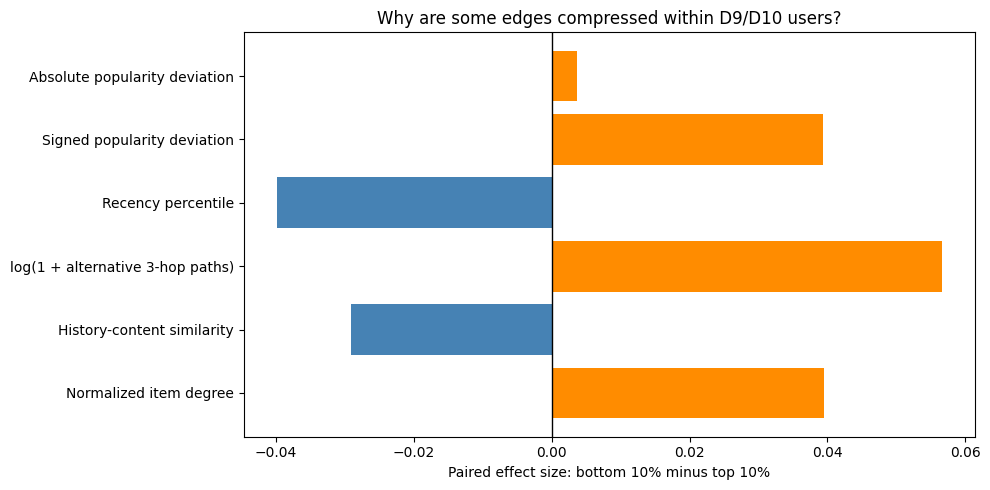

In [ ]:
plot_data = comparison_summary[
    comparison_summary["hub_group"] == "D9 + D10"
].copy()

fig, ax = plt.subplots(figsize=(10, 5))

colors = np.where(
    plot_data["paired_effect_dz"] >= 0,
    "darkorange",
    "steelblue",
)

ax.barh(
    plot_data["metric"],
    plot_data["paired_effect_dz"],
    color=colors,
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Paired effect size: bottom 10% minus top 10%")
ax.set_title(
    "Why are some edges compressed within D9/D10 users?"
)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import spearmanr

USER_COL = "userID"
ITEM_COL = "itemID"

base_analysis = edge_analysis.copy().reset_index(drop=True)

# ------------------------------------------------
# Xác định D9 và D10 hub users
# ------------------------------------------------
user_degree_table = (
    base_analysis.groupby(USER_COL)
    .size()
    .rename("original_degree")
    .reset_index()
)

user_degree_table["degree_decile"] = pd.qcut(
    user_degree_table["original_degree"].rank(method="first"),
    q=10,
    labels=range(1, 11),
).astype(int)

degree_decile_map = user_degree_table.set_index(
    USER_COL
)["degree_decile"]

base_analysis["degree_decile"] = (
    base_analysis[USER_COL].map(degree_decile_map)
)

hub_edges = (
    base_analysis[
        base_analysis["degree_decile"].isin([9, 10])
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"D9/D10 users: {hub_edges[USER_COL].nunique():,}")
print(f"D9/D10 edges: {len(hub_edges):,}")

D9/D10 users: 2,200
D9/D10 edges: 63,665


In [ ]:
all_users = base_analysis[USER_COL].to_numpy(dtype=np.int64)
all_items = base_analysis[ITEM_COL].to_numpy(dtype=np.int64)

num_users = int(all_users.max()) + 1
num_items = int(all_items.max()) + 1

adjacency = sp.coo_matrix(
    (
        np.ones(len(base_analysis), dtype=np.int64),
        (all_users, all_items),
    ),
    shape=(num_users, num_items),
).tocsr()

adjacency.sum_duplicates()

if adjacency.nnz != len(base_analysis):
    raise ValueError(
        "Có duplicate user-item interactions. "
        "Alternative-path definition cần được điều chỉnh."
    )

adjacency.data[:] = 1
adjacency_t = adjacency.T.tocsr()

graph_user_degree = np.asarray(
    adjacency.sum(axis=1)
).ravel()

graph_item_degree = np.asarray(
    adjacency.sum(axis=0)
).ravel()

In [ ]:
target_users = hub_edges[USER_COL].to_numpy(dtype=np.int64)
target_items = hub_edges[ITEM_COL].to_numpy(dtype=np.int64)

alternative_paths = np.zeros(
    len(hub_edges),
    dtype=np.int64,
)

positions_by_user = hub_edges.groupby(
    USER_COL,
    sort=False,
).indices

hub_user_ids = np.array(
    sorted(positions_by_user),
    dtype=np.int64,
)

BATCH_SIZE = 32

for start in range(0, len(hub_user_ids), BATCH_SIZE):
    batch_users = hub_user_ids[start:start + BATCH_SIZE]

    # Tổng length-3 walks:
    # A A^T A
    batch_walks = (
        (adjacency[batch_users] @ adjacency_t)
        @ adjacency
    ).tocsr()

    position_parts = []
    local_row_parts = []

    for local_row, user_id in enumerate(batch_users):
        positions = positions_by_user[int(user_id)]

        position_parts.append(positions)
        local_row_parts.append(
            np.full(
                len(positions),
                local_row,
                dtype=np.int64,
            )
        )

    positions = np.concatenate(position_parts)
    local_rows = np.concatenate(local_row_parts)
    item_columns = target_items[positions]

    pair_values = batch_walks[local_rows, item_columns]

    if sp.issparse(pair_values):
        pair_values = pair_values.toarray()

    walk_counts = np.asarray(pair_values).reshape(-1)

    # Loại các backtracking paths.
    valid_paths = (
        walk_counts
        - graph_user_degree[target_users[positions]]
        - graph_item_degree[target_items[positions]]
        + 1
    )

    alternative_paths[positions] = np.maximum(
        valid_paths,
        0,
    )

    print(
        f"\rProcessed "
        f"{min(start + BATCH_SIZE, len(hub_user_ids)):,}"
        f"/{len(hub_user_ids):,} hub users",
        end="",
    )

print()

hub_edges["alternative_3hop_paths"] = alternative_paths
hub_edges["log_alternative_paths"] = np.log1p(
    alternative_paths
)

display(
    hub_edges["alternative_3hop_paths"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
)

Processed 2,200/2,200 hub users


count    63665.000000
mean        22.064431
std         34.976202
min          0.000000
25%          4.000000
50%         10.000000
75%         25.000000
90%         55.000000
99%        170.000000
max        738.000000
Name: alternative_3hop_paths, dtype: float64

In [ ]:
N_QUANTILES = 10

quantile_codes = pd.qcut(
    hub_edges["alternative_3hop_paths"],
    q=N_QUANTILES,
    labels=False,
    duplicates="drop",
)

if quantile_codes.isna().all():
    raise ValueError(
        "Alternative-path count không có đủ variation."
    )

hub_edges["path_quantile"] = (
    quantile_codes.astype(int) + 1
)

actual_quantiles = sorted(
    hub_edges["path_quantile"].unique()
)

global_path_summary = (
    hub_edges.groupby("path_quantile", observed=True)
    .agg(
        n_edges=("mask", "size"),
        path_min=("alternative_3hop_paths", "min"),
        path_median=("alternative_3hop_paths", "median"),
        path_max=("alternative_3hop_paths", "max"),
        mean_mask=("mask", "mean"),
        median_mask=("mask", "median"),
        mask_std=("mask", "std"),
    )
    .reindex(actual_quantiles)
)

global_path_summary["mask_sem"] = (
    global_path_summary["mask_std"]
    / np.sqrt(global_path_summary["n_edges"])
)

global_path_summary["ci95"] = (
    1.96 * global_path_summary["mask_sem"]
)

display(global_path_summary.round(6))

,n_edges,path_min,path_median,path_max,mean_mask,median_mask,mask_std,mask_sem,ci95
path_quantile,,,,,,,,,
1,7949,0,1.0,1,0.944804,0.976244,0.098315,0.001103,0.002161
2,7405,2,2.0,3,0.944939,0.975406,0.094637,0.001100,0.002156
3,6064,4,4.0,5,0.940952,0.975365,0.103842,0.001334,0.002614
4,4946,6,6.0,7,0.944098,0.975470,0.097533,0.001387,0.002718
5,5995,8,9.0,10,0.941827,0.974555,0.098327,0.001270,0.002489
6,6941,11,13.0,15,0.940764,0.974729,0.103013,0.001236,0.002423
7,5717,16,18.0,21,0.941596,0.975180,0.100111,0.001324,0.002595
8,5935,22,26.0,31,0.939082,0.975117,0.105024,0.001363,0.002672
9,6522,32,41.0,55,0.934698,0.972862,0.110466,0.001368,0.002681


In [ ]:
hub_edges["within_user_path_percentile"] = (
    hub_edges.groupby(USER_COL)[
        "alternative_3hop_paths"
    ]
    .rank(method="average", pct=True)
)

hub_edges["within_user_path_quantile"] = np.ceil(
    hub_edges["within_user_path_percentile"]
    * N_QUANTILES
).clip(1, N_QUANTILES).astype(int)

# Mean mask của mỗi user trong mỗi quantile.
per_user_path_summary = (
    hub_edges.groupby(
        [USER_COL, "within_user_path_quantile"],
        observed=True,
    )
    .agg(
        user_mean_mask=("mask", "mean"),
        user_mean_paths=("alternative_3hop_paths", "mean"),
    )
    .reset_index()
)

# Sau đó average ngang qua users để mỗi user có trọng số bằng nhau.
within_user_summary = (
    per_user_path_summary.groupby(
        "within_user_path_quantile",
        observed=True,
    )
    .agg(
        n_users=(USER_COL, "nunique"),
        mean_mask=("user_mean_mask", "mean"),
        median_mask=("user_mean_mask", "median"),
        mask_std=("user_mean_mask", "std"),
        mean_paths=("user_mean_paths", "mean"),
    )
    .reindex(range(1, N_QUANTILES + 1))
)

within_user_summary["mask_sem"] = (
    within_user_summary["mask_std"]
    / np.sqrt(within_user_summary["n_users"])
)

within_user_summary["ci95"] = (
    1.96 * within_user_summary["mask_sem"]
)

display(within_user_summary.round(6))

,n_users,mean_mask,median_mask,mask_std,mean_paths,mask_sem,ci95
within_user_path_quantile,,,,,,,
1,1723,0.944773,0.970578,0.075121,1.709467,0.001810,0.003547
2,1891,0.943843,0.969345,0.074515,4.169705,0.001714,0.003359
3,1795,0.943621,0.969387,0.068348,7.116418,0.001613,0.003162
4,1795,0.943233,0.968868,0.069508,9.929264,0.001641,0.003216
5,1903,0.943437,0.968883,0.073743,12.646511,0.001690,0.003313
6,1833,0.943985,0.968964,0.070580,16.400609,0.001649,0.003231
7,1955,0.942679,0.970065,0.076279,19.654114,0.001725,0.003381
8,2032,0.944470,0.969546,0.072509,24.078886,0.001609,0.003153
9,2114,0.942688,0.968774,0.076090,30.198388,0.001655,0.003244


In [ ]:
global_rho, global_p = spearmanr(
    hub_edges["alternative_3hop_paths"],
    hub_edges["mask"],
)

# Center mask theo từng user để loại user-specific mask baseline.
hub_edges["user_centered_mask"] = (
    hub_edges["mask"]
    - hub_edges.groupby(USER_COL)["mask"].transform("mean")
)

within_rho, within_p = spearmanr(
    hub_edges["within_user_path_percentile"],
    hub_edges["user_centered_mask"],
)

global_means = global_path_summary["mean_mask"].dropna()
within_means = within_user_summary["mean_mask"].dropna()

global_downward_fraction = np.mean(
    np.diff(global_means) < 0
)

within_downward_fraction = np.mean(
    np.diff(within_means) < 0
)

diagnostics = pd.Series({
    "Global Spearman rho": global_rho,
    "Global Spearman p": global_p,
    "Within-user Spearman rho": within_rho,
    "Within-user Spearman p": within_p,
    "Global highest-Q minus lowest-Q": (
        global_means.iloc[-1] - global_means.iloc[0]
    ),
    "Within highest-Q minus lowest-Q": (
        within_means.iloc[-1] - within_means.iloc[0]
    ),
    "Global fraction downward steps": global_downward_fraction,
    "Within fraction downward steps": within_downward_fraction,
})

display(diagnostics.to_frame("value").round(6))

,value
Global Spearman rho,-0.040902
Global Spearman p,0.000000
Within-user Spearman rho,-0.007431
Within-user Spearman p,0.060806
Global highest-Q minus lowest-Q,-0.011396
Within highest-Q minus lowest-Q,0.000309
Global fraction downward steps,0.666667
Within fraction downward steps,0.555556


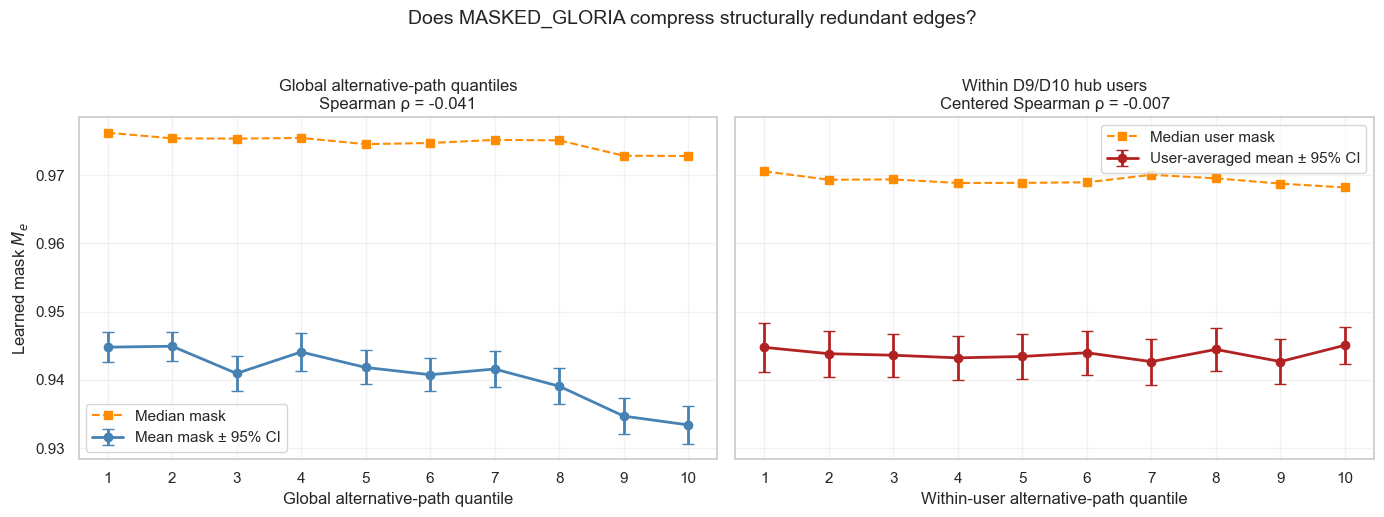

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True,
)

# ------------------------------------------------
# Global quantiles
# ------------------------------------------------
axes[0].errorbar(
    global_path_summary.index,
    global_path_summary["mean_mask"],
    yerr=global_path_summary["ci95"],
    marker="o",
    markersize=6,
    linewidth=2,
    capsize=4,
    color="steelblue",
    label="Mean mask ± 95% CI",
)

axes[0].plot(
    global_path_summary.index,
    global_path_summary["median_mask"],
    marker="s",
    linestyle="--",
    color="darkorange",
    label="Median mask",
)

axes[0].set_xlabel("Global alternative-path quantile")
axes[0].set_ylabel(r"Learned mask $M_e$")
axes[0].set_title(
    "Global alternative-path quantiles\n"
    f"Spearman ρ = {global_rho:.3f}"
)
axes[0].set_xticks(global_path_summary.index)
axes[0].legend()
axes[0].grid(alpha=0.25)

# ------------------------------------------------
# Within-user quantiles
# ------------------------------------------------
axes[1].errorbar(
    within_user_summary.index,
    within_user_summary["mean_mask"],
    yerr=within_user_summary["ci95"],
    marker="o",
    markersize=6,
    linewidth=2,
    capsize=4,
    color="firebrick",
    label="User-averaged mean ± 95% CI",
)

axes[1].plot(
    within_user_summary.index,
    within_user_summary["median_mask"],
    marker="s",
    linestyle="--",
    color="darkorange",
    label="Median user mask",
)

axes[1].set_xlabel("Within-user alternative-path quantile")
axes[1].set_title(
    "Within D9/D10 hub users\n"
    f"Centered Spearman ρ = {within_rho:.3f}"
)
axes[1].set_xticks(range(1, N_QUANTILES + 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.suptitle(
    "Does MASKED_GLORIA compress structurally redundant edges?",
    fontsize=14,
    y=1.03,
)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from matplotlib.ticker import PercentFormatter

USER_COL = "userID"
ITEM_COL = "itemID"

analysis = edge_analysis.copy().reset_index(drop=True)

# Nếu chưa có raw user degree thì tính từ training edges.
if "user_degree" not in analysis.columns:
    analysis["user_degree"] = (
        analysis.groupby(USER_COL)[ITEM_COL]
        .transform("size")
    )

# Delta_e = 1 - M_e
analysis["drop"] = 1.0 - analysis["mask"]

if not analysis["drop"].between(0, 1).all():
    raise ValueError("Mask/drop nằm ngoài khoảng [0, 1].")

degree_bins = [0, 5, 20, 50, np.inf]

degree_labels = [
    "1–5",
    "6–20",
    "21–50",
    "51+",
]

analysis["user_degree_group"] = pd.cut(
    analysis["user_degree"],
    bins=degree_bins,
    labels=degree_labels,
    include_lowest=True,
    right=True,
)

In [ ]:
edge_weighted_summary = (
    analysis.groupby("user_degree_group", observed=True)
    .agg(
        n_edges=("drop", "size"),
        n_users=(USER_COL, "nunique"),
        mean_mask=("mask", "mean"),
        mean_drop=("drop", "mean"),
        median_drop=("drop", "median"),
        drop_std=("drop", "std"),
        drop_p25=("drop", lambda x: np.percentile(x, 25)),
        drop_p75=("drop", lambda x: np.percentile(x, 75)),
    )
    .reindex(degree_labels)
)

display(edge_weighted_summary.round(6))

,n_edges,n_users,mean_mask,mean_drop,median_drop,drop_std,drop_p25,drop_p75
user_degree_group,,,,,,,,
1–5,14080,3631,0.955620,0.044380,0.023036,0.074011,0.014762,0.041535
6–20,59910,6215,0.952786,0.047214,0.023103,0.080316,0.014658,0.043159
21–50,27144,902,0.940936,0.059064,0.025100,0.102297,0.015258,0.051339
51+,19330,252,0.933247,0.066753,0.027137,0.112587,0.015849,0.059839


In [ ]:
user_drop = (
    analysis.groupby(USER_COL)
    .agg(
        user_degree=("user_degree", "first"),
        mean_drop=("drop", "mean"),
        median_drop=("drop", "median"),
        effective_degree=("mask", "sum"),
    )
    .reset_index()
)

user_drop["user_degree_group"] = pd.cut(
    user_drop["user_degree"],
    bins=degree_bins,
    labels=degree_labels,
    include_lowest=True,
    right=True,
)

user_weighted_summary = (
    user_drop.groupby("user_degree_group", observed=True)
    .agg(
        n_users=(USER_COL, "size"),
        mean_user_drop=("mean_drop", "mean"),
        median_user_drop=("mean_drop", "median"),
        std_user_drop=("mean_drop", "std"),
    )
    .reindex(degree_labels)
)

user_weighted_summary["sem"] = (
    user_weighted_summary["std_user_drop"]
    / np.sqrt(user_weighted_summary["n_users"])
)

user_weighted_summary["ci95"] = (
    1.96 * user_weighted_summary["sem"]
)

display(user_weighted_summary.round(6))

,n_users,mean_user_drop,median_user_drop,std_user_drop,sem,ci95
user_degree_group,,,,,,
1–5,3631,0.044181,0.027432,0.049893,0.000828,0.001623
6–20,6215,0.046054,0.030773,0.044662,0.000567,0.001110
21–50,902,0.058655,0.040131,0.051645,0.001720,0.003370
51+,252,0.064401,0.048450,0.046564,0.002933,0.005749


In [ ]:
spearman_rho, spearman_p = spearmanr(
    user_drop["user_degree"],
    user_drop["mean_drop"],
)

edge_means = (
    edge_weighted_summary["mean_drop"]
    .dropna()
)

user_means = (
    user_weighted_summary["mean_user_drop"]
    .dropna()
)

diagnostics = pd.Series({
    "Overall mean mask": analysis["mask"].mean(),
    "Overall mean drop": analysis["drop"].mean(),
    "Spearman rho: user degree vs mean drop": spearman_rho,
    "Spearman p": spearman_p,
    "Edge-weighted 51+ minus 1–5": (
        edge_weighted_summary.loc["51+", "mean_drop"]
        - edge_weighted_summary.loc["1–5", "mean_drop"]
    ),
    "User-weighted 51+ minus 1–5": (
        user_weighted_summary.loc["51+", "mean_user_drop"]
        - user_weighted_summary.loc["1–5", "mean_user_drop"]
    ),
    "Edge means monotonically increasing": bool(
        np.all(np.diff(edge_means) >= 0)
    ),
    "User means monotonically increasing": bool(
        np.all(np.diff(user_means) >= 0)
    ),
})

display(diagnostics.to_frame("value"))

,value
Overall mean mask,0.947312
Overall mean drop,0.052688
Spearman rho: user degree vs mean drop,0.190917
Spearman p,0.0
Edge-weighted 51+ minus 1–5,0.022374
User-weighted 51+ minus 1–5,0.02022
Edge means monotonically increasing,True
User means monotonically increasing,True


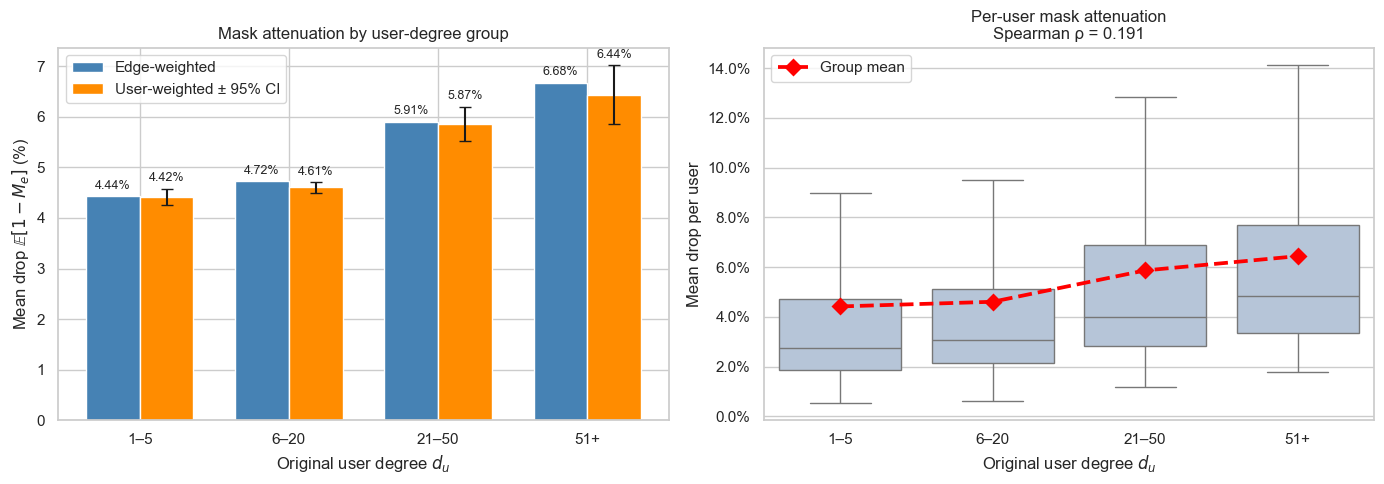

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

x = np.arange(len(degree_labels))
width = 0.36

edge_drop_percent = (
    edge_weighted_summary["mean_drop"].to_numpy() * 100
)

user_drop_percent = (
    user_weighted_summary["mean_user_drop"].to_numpy() * 100
)

user_ci_percent = (
    user_weighted_summary["ci95"].to_numpy() * 100
)

edge_bars = axes[0].bar(
    x - width / 2,
    edge_drop_percent,
    width,
    color="steelblue",
    label="Edge-weighted",
)

user_bars = axes[0].bar(
    x + width / 2,
    user_drop_percent,
    width,
    yerr=user_ci_percent,
    capsize=4,
    color="darkorange",
    label="User-weighted ± 95% CI",
)

axes[0].bar_label(
    edge_bars,
    fmt="%.2f%%",
    padding=3,
    fontsize=9,
)

axes[0].bar_label(
    user_bars,
    fmt="%.2f%%",
    padding=3,
    fontsize=9,
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(degree_labels)
axes[0].set_xlabel(r"Original user degree $d_u$")
axes[0].set_ylabel(r"Mean drop $\mathbb{E}[1-M_e]$ (%)")
axes[0].set_title("Mask attenuation by user-degree group")
axes[0].legend()

# Phân phối mean drop ở cấp user
sns.boxplot(
    data=user_drop,
    x="user_degree_group",
    y="mean_drop",
    order=degree_labels,
    showfliers=False,
    color="lightsteelblue",
    ax=axes[1],
)

sns.pointplot(
    data=user_drop,
    x="user_degree_group",
    y="mean_drop",
    order=degree_labels,
    estimator="mean",
    errorbar=None,
    color="red",
    markers="D",
    linestyles="--",
    ax=axes[1],
    label="Group mean",
)

axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

axes[1].set_xlabel(r"Original user degree $d_u$")
axes[1].set_ylabel("Mean drop per user")
axes[1].set_title(
    "Per-user mask attenuation\n"
    f"Spearman ρ = {spearman_rho:.3f}"
)
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path(
    r"C:\study\Master_papers\Robust MM\CaMuRe"
)

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from utils.configurator import Config
from utils.dataset import RecDataset
from utils.dataloader import TrainDataLoader, EvalDataLoader
from utils.utils import get_model, get_trainer, init_seed


MODEL_NAME = "MASKED_GLORIA"
DATASET_NAME = "book"

checkpoint_path = PROJECT_ROOT / (
    r"saved\MASKED_GLORIA-book-seed999-"
    r"Aug-12-2026-13-46-25.pth"
)

# Phải khớp với training configuration.
config_dict = {
    "gpu_id": 0,
    "use_gpu": True,
    "fusion": "add",
    "seed": 999,
    "knn_k": 10,
    "n_mm_layers": 1,
    "aggr_mode": "add",
    "reg_weight": 0.01,
    "learning_rate": 0.0001,

    # Không ghi recommendation files khi evaluate nhiều lần.
    "save_recommended_topk": False,
}

config = Config(
    model=MODEL_NAME,
    dataset=DATASET_NAME,
    config_dict=config_dict,
)

init_seed(config["seed"])

dataset = RecDataset(config)
train_dataset, valid_dataset, test_dataset = dataset.split()


train_data = TrainDataLoader(
    config,
    train_dataset,
    batch_size=config["train_batch_size"],
    shuffle=True,
)

valid_data = EvalDataLoader(
    config,
    valid_dataset,
    additional_dataset=train_dataset,
    batch_size=config["eval_batch_size"],
)

test_data = EvalDataLoader(
    config,
    test_dataset,
    additional_dataset=train_dataset,
    batch_size=config["eval_batch_size"],
)

train_data.pretrain_setup()

model = get_model(MODEL_NAME)(
    config,
    train_data,
).to(config["device"])

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=config["device"],
        weights_only=True,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=config["device"],
    )

state_dict = checkpoint.get("state_dict", checkpoint)
model.load_state_dict(state_dict, strict=True)

trainer = get_trainer()(config, model)

print(f"Loaded: {checkpoint_path.name}")

Loading pre-extracted features from C:\study\Master_papers\Robust MM\CaMuRe\data\book\text_feat.npy
number of users: 11000, number of items: 9332


RuntimeError: Error(s) in loading state_dict for MASKED_GLORIA:
	Missing key(s) in state_dict: "full_gcn.preference", "mask_gcn.preference". 
	Unexpected key(s) in state_dict: "full_preference", "mask_preference". 

In [ ]:
print(train_dataset.inter_num)
print(valid_dataset.inter_num)
print(test_dataset.inter_num)

In [11]:
@torch.no_grad()
def recompute_result_embeddings(model):
    model.eval()

    device = model.mask_logits.device

    dummy_user = torch.zeros(
        1,
        dtype=torch.long,
        device=device,
    )

    dummy_positive = torch.zeros(
        1,
        dtype=torch.long,
        device=device,
    )

    dummy_negative = torch.zeros(
        1,
        dtype=torch.long,
        device=device,
    )

    # forward() recompute toàn bộ graph representations.
    model.forward(
        (
            dummy_user,
            dummy_positive,
            dummy_negative,
        )
    )


@torch.no_grad()
def evaluate_current_mask(model, trainer, eval_data):
    recompute_result_embeddings(model)

    # is_test=False để không ghi recommendation file.
    return trainer.evaluate(
        eval_data,
        is_test=False,
    )